# Forecasting the exports volume of processed seafood in Thailand

## 1. Importing Required Libraries
In this cell, we load all the necessary Python libraries used for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`), and machine learning model creation and evaluation (`scikit-learn`).

In [24]:
# Importing standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# Importing machine learning tools
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score

## 2. Convert Excel File to CSV 
This script loads an Excel file using the `pandas` library and converts it to a CSV file.

It uses UTF-8 with BOM encoding to ensure compatibility with Excel and excludes the index column from the output.

In [2]:
# Load the .xlsx file (default sheet)
df = pd.read_excel('DATA/DGA_Main_115kV.xlsx')  # tu peux ajouter sheet_name='NomDeLaFeuille' si nécessaire

# Save as .csv
df.to_csv('DATA/DGA_Main_115kV.csv', index=False,encoding="utf-8-sig")  # index=False pour ne pas inclure la colonne d’index

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# --- Chargement des données ---
df = pd.read_csv("DATA/DGA_Main_115kV.csv")
df = df.drop(columns=["Unnamed: 20", "Unnamed: 21"], errors='ignore')
df = df.dropna(subset=["Year Test"])
df["Year Test"] = df["Year Test"].astype(int)

# --- Suppression des lignes où toutes les colonnes clés sont à 0 ---
def supprimer_lignes_tous_zero_colonnes(df, colonnes):
    return df[~df[colonnes].eq(0.0).all(axis=1)]

colonnes_a_verifier = [
    'MFG', 'KV', 'MVA', 'Age', 'Year Test', 'O2', 'N2', 'CO2', 'CO',
    'H2', 'CH4', 'C2H2', 'C2H4', 'C2H6', 'C3H6', 'C3H8', 'TCG', 'TEMP', 'WATER'
]
df = supprimer_lignes_tous_zero_colonnes(df, colonnes_a_verifier)

# --- Caractéristique temporelle ---
df["year_num"] = df["Year Test"] - df["Year Test"].min()

# --- Calcul des ratios nécessaires ---
df["R1"] = df["CH4"] / df["H2"].replace(0, np.nan)      # CH4/H2 (R1)
df["R2"] = df["C2H2"] / df["C2H4"].replace(0, np.nan)   # C2H2/C2H4 (R2)
df["R3"] = df["C2H2"] / df["CH4"].replace(0, np.nan)    # C2H2/CH4 (R3)
df["R4"] = df["C2H6"] / df["C2H2"].replace(0, np.nan)   # C2H6/C2H2 (R4)
df["R5"] = df["C2H4"] / df["C2H6"].replace(0, np.nan)   # C2H4/C2H6 (R5)
df["Duval_Total"] = df[["CH4", "C2H2", "C2H4"]].sum(axis=1).replace(0, np.nan)

# === Fonctions de classification avec mapping vers les classes standardisées ===

# IRM (avec mapping)
def classify_IRM(row):
    R1, R2, R5 = row["R1"], row["R2"], row["R5"]
    if pd.isna(R1) or pd.isna(R2) or pd.isna(R5):
        return "Uncertain"
    if R1 < 0.1 and R5 < 0.2:
        return "PD"
    elif R1 < 0.1 and R2 > 1 and R5 > 1:
        return "PD"  # Low Energy Discharge classée PD
    elif 0.1 <= R1 <= 1 and 0.6 <= R2 <= 2.5 and R5 > 2:
        return "D1"  # High Energy Discharge → D1
    elif R5 < 1:
        return "F1"  # Thermal fault < 300°C → F1
    elif R1 > 1 and R2 < 0.1 and 1 <= R5 <= 4:
        return "T2"  # Thermal fault 300-700°C → T2
    elif R1 > 1 and R2 < 0.2 and R5 > 4:
        return "T3"  # Thermal fault > 700°C → T3
    else:
        return "Uncertain"

# DRM (mapping avec seuils stricts)
def classify_DRM(row):
    if pd.isna(row["R1"]) or pd.isna(row["R2"]) or pd.isna(row["R3"]) or pd.isna(row["R4"]):
        return "Uncertain"
    if not (row["H2"] > 100 and (row["CH4"] > 120 or row["C2H2"] > 1 or row["C2H4"] > 50)):
        return "Uncertain"

    R1, R2, R3, R4 = row["R1"], row["R2"], row["R3"], row["R4"]

    if R1 > 1 and R2 < 0.75 and R3 < 0.3 and R4 > 0.4:
        return "F1"  # Thermal Decomposition → F1
    elif R1 < 0.1 and R3 < 0.3 and R4 > 0.4:
        return "PD"
    elif 0.1 <= R1 <= 1 and R2 > 0.75 and R3 < 0.3 and R4 < 0.4:
        return "D2"  # Arcing → D2
    else:
        return "Uncertain"

# RRM (avec mapping)
def classify_RRM(row):
    if pd.isna(row["R1"]) or pd.isna(row["R2"]) or pd.isna(row["R5"]):
        return "Uncertain"
    if row[["CH4", "H2", "C2H2", "C2H4", "C2H6"]].min() <= 0:
        return "Uncertain"

    R1, R2, R5 = row["R1"], row["R2"], row["R5"]

    if 0.1 <= R1 <= 1 and R2 < 0.1 and R5 < 1:
        return "F1"  # Normal
    elif R1 < 0.1 and R2 < 0.1 and R5 < 1:
        return "PD"
    elif 0.1 <= R1 <= 1 and 0.1 <= R2 <= 3 and R5 > 3:
        return "D2"  # Arcing
    elif 0.1 <= R1 <= 1 and R2 < 0.1 and 1 <= R5 <= 3:
        return "T1"  # Low Temp Thermal
    elif R1 > 1 and R2 < 0.1 and 1 <= R5 <= 3:
        return "T2"
    elif R1 > 1 and R2 < 0.1 and R5 > 3:
        return "T3"
    else:
        return "Uncertain"

# Duval Triangle Method (DTM)
def classify_DTM(row):
    ch4, c2h2, c2h4 = row["CH4"], row["C2H2"], row["C2H4"]
    total = ch4 + c2h2 + c2h4
    if total == 0:
        return "Uncertain"
    pct_ch4 = 100 * ch4 / total
    pct_c2h2 = 100 * c2h2 / total
    pct_c2h4 = 100 * c2h4 / total

    if pct_c2h2 > 23 and pct_c2h4 < 40:
        return "PD"
    elif pct_c2h4 > 40 and pct_c2h2 < 23:
        return "T2"
    elif 23 <= pct_c2h2 <= 50 and 20 <= pct_c2h4 <= 50:
        return "D1"  # Discharge fault
    elif pct_c2h4 < 20 and pct_c2h2 < 23:
        return "T1"
    else:
        return "Uncertain"

# Duval Pentagon Method (DPM)
def classify_DPM(row):
    ch4, c2h2, c2h4, h2, c2h6 = row["CH4"], row["C2H2"], row["C2H4"], row["H2"], row["C2H6"]
    total = ch4 + c2h2 + c2h4 + h2 + c2h6
    if total == 0:
        return "Uncertain"
    pct_ch4 = 100 * ch4 / total
    pct_c2h2 = 100 * c2h2 / total
    pct_c2h4 = 100 * c2h4 / total
    pct_h2 = 100 * h2 / total
    pct_c2h6 = 100 * c2h6 / total

    if pct_c2h2 > 20 and pct_h2 > 15:
        return "PD"
    elif pct_c2h4 > 40 and pct_c2h6 < 10:
        return "T1"  # Thermal fault (low energy)
    elif pct_c2h6 > 10 and pct_ch4 > 15:
        return "T3"  # Thermal fault (high energy)
    else:
        return "Uncertain"

# === Application des classifications ===
df["IRM_fault"] = df.apply(classify_IRM, axis=1)
df["DRM_fault"] = df.apply(classify_DRM, axis=1)
df["RRM_fault"] = df.apply(classify_RRM, axis=1)
df["DTM_fault"] = df.apply(classify_DTM, axis=1)
df["DPM_fault"] = df.apply(classify_DPM, axis=1)

# --- Vote majoritaire ---
def majority_vote(row):
    votes = [
        row["IRM_fault"],
        row["DRM_fault"],
        row["RRM_fault"],
        row["DTM_fault"],
        row["DPM_fault"]
    ]
    votes = [v for v in votes if v != "Uncertain"]
    if not votes:
        return "Uncertain"
    vote_count = Counter(votes)
    # Prendre la classe la plus fréquente, en cas d'égalité, retourne une des classes (le plus commun)
    return vote_count.most_common(1)[0][0]

df["fault_majority_vote"] = df.apply(majority_vote, axis=1)

# --- Encodage numérique de la décision finale ---
label_encoder = LabelEncoder()
df["faults_index"] = label_encoder.fit_transform(df["fault_majority_vote"])

# --- Affichage du mapping pour référence ---
print("### Index des classes de défaillance (majority vote) ###")
fault_labels = {i: label for i, label in enumerate(label_encoder.classes_)}
for idx, label in fault_labels.items():
    print(f"{idx} - {label}")

# --- Tri et sauvegarde ---
if "Tr." in df.columns:
    df = df.sort_values("Tr.")
df.to_csv("DATA/DGA_Main_115kV.csv", index=False)


### Index des classes de défaillance (majority vote) ###
0 - D1
1 - D2
2 - F1
3 - PD
4 - T1
5 - T2
6 - T3
7 - Uncertain


## 2. Data Loading, Cleaning, and Feature Engineering
In this section, we prepare the export dataset for modeling. The process includes:
- Loading the CSV file containing monthly seafood export records from 2007 to 2024.
- Creating a datetime column by combining the Year and Month columns, enabling proper chronological sorting and time-based analysis.
- Filtering the dataset by removing rows where all product-related quantities and values are equal to zero, as these records likely represent missing or irrelevant data.
- Sorting the dataset by date to preserve temporal order.
- Generating a numerical time feature called month_num, which represents the number of months elapsed since the beginning of the dataset. This variable is used as the main input for forecasting models.


=== Logistic Regression ===

Classification report (fold 1):
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00         6
          D2       0.00      0.00      0.00         5
          F1       0.80      1.00      0.89       172
          PD       0.00      0.00      0.00        22
          T1       0.00      0.00      0.00         0
          T2       0.00      0.00      0.00         0
          T3       0.00      0.00      0.00         6
   Uncertain       0.00      0.00      0.00         3

    accuracy                           0.80       214
   macro avg       0.10      0.12      0.11       214
weighted avg       0.65      0.80      0.72       214


Classification report (fold 2):
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00         7
          D2       0.00      0.00      0.00         9
          F1       0.58      1.00      0.74       125
          PD       0.00      0.00    

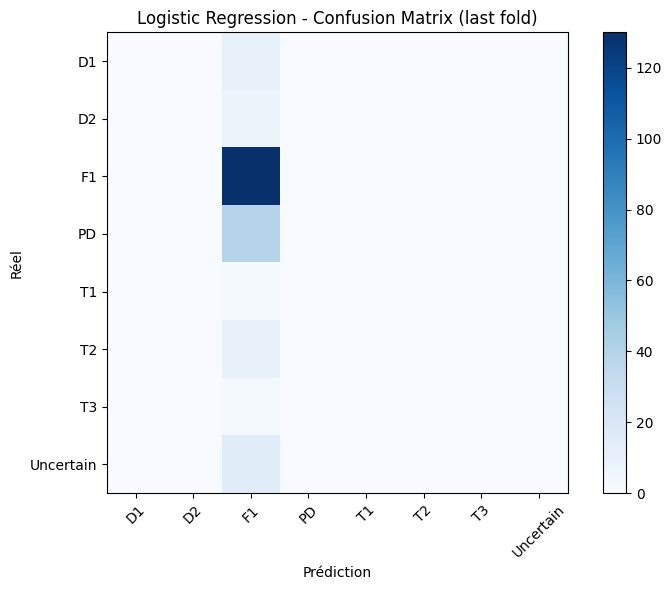


Classification report (fold 5):
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00        10
          D2       0.00      0.00      0.00         7
          F1       0.61      1.00      0.76       130
          PD       0.00      0.00      0.00        39
          T1       0.00      0.00      0.00         2
          T2       0.00      0.00      0.00         9
          T3       0.00      0.00      0.00         2
   Uncertain       0.00      0.00      0.00        15

    accuracy                           0.61       214
   macro avg       0.08      0.12      0.09       214
weighted avg       0.37      0.61      0.46       214


=== SVC ===

Classification report (fold 1):
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00         6
          D2       0.00      0.00      0.00         5
          F1       0.80      1.00      0.89       172
          PD       0.00      0.00      0.00        22

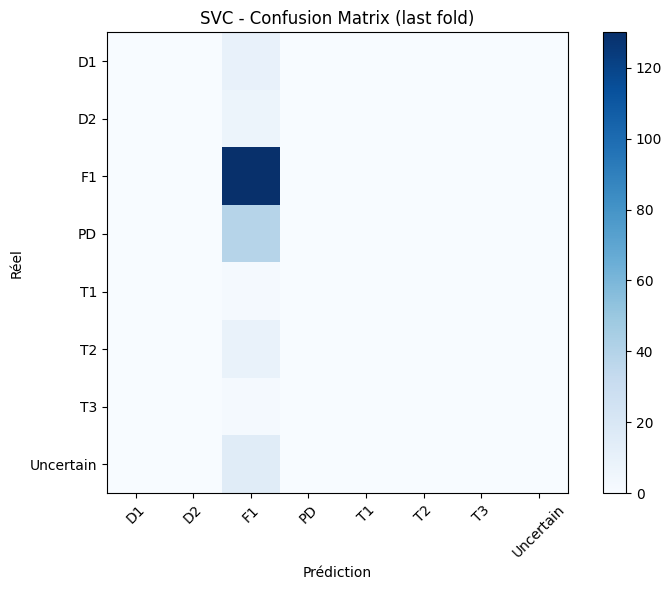


Classification report (fold 5):
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00        10
          D2       0.00      0.00      0.00         7
          F1       0.61      1.00      0.76       130
          PD       0.00      0.00      0.00        39
          T1       0.00      0.00      0.00         2
          T2       0.00      0.00      0.00         9
          T3       0.00      0.00      0.00         2
   Uncertain       0.00      0.00      0.00        15

    accuracy                           0.61       214
   macro avg       0.08      0.12      0.09       214
weighted avg       0.37      0.61      0.46       214


=== Decision Tree ===

Classification report (fold 1):
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00         6
          D2       0.00      0.00      0.00         5
          F1       0.80      1.00      0.89       172
          PD       0.00      0.00      0.00

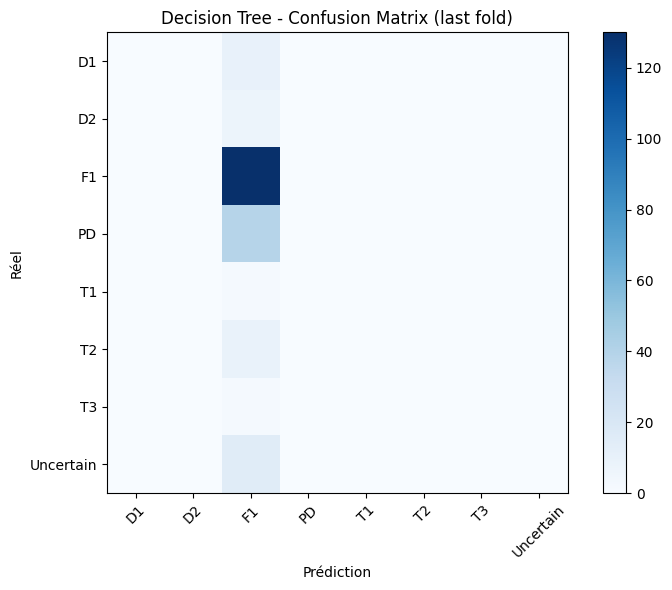


Classification report (fold 5):
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00        10
          D2       0.00      0.00      0.00         7
          F1       0.61      1.00      0.76       130
          PD       0.00      0.00      0.00        39
          T1       0.00      0.00      0.00         2
          T2       0.00      0.00      0.00         9
          T3       0.00      0.00      0.00         2
   Uncertain       0.00      0.00      0.00        15

    accuracy                           0.61       214
   macro avg       0.08      0.12      0.09       214
weighted avg       0.37      0.61      0.46       214


=== Random Forest ===

Classification report (fold 1):
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00         6
          D2       0.00      0.00      0.00         5
          F1       0.80      0.98      0.88       172
          PD       0.00      0.00      0.00

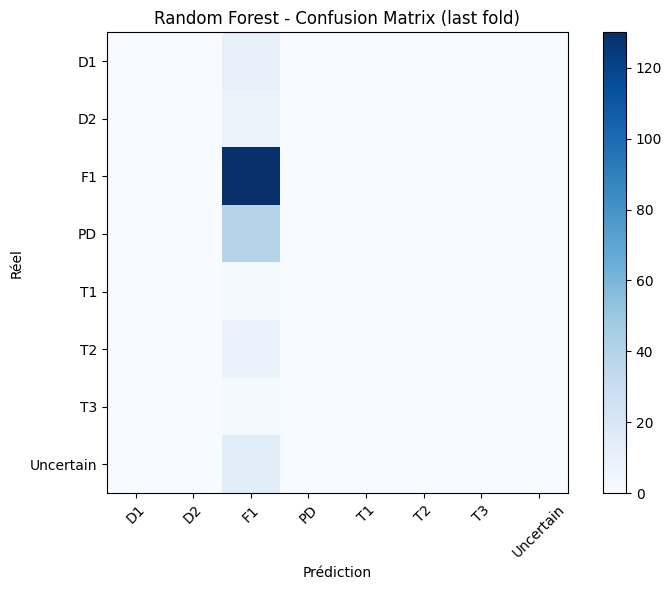


Classification report (fold 5):
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00        10
          D2       0.00      0.00      0.00         7
          F1       0.61      1.00      0.76       130
          PD       0.00      0.00      0.00        39
          T1       0.00      0.00      0.00         2
          T2       0.00      0.00      0.00         9
          T3       0.00      0.00      0.00         2
   Uncertain       0.00      0.00      0.00        15

    accuracy                           0.61       214
   macro avg       0.08      0.12      0.09       214
weighted avg       0.37      0.61      0.46       214


=== KNN ===

Classification report (fold 1):
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00         6
          D2       0.00      0.00      0.00         5
          F1       0.80      0.45      0.58       172
          PD       0.10      0.55      0.17        22

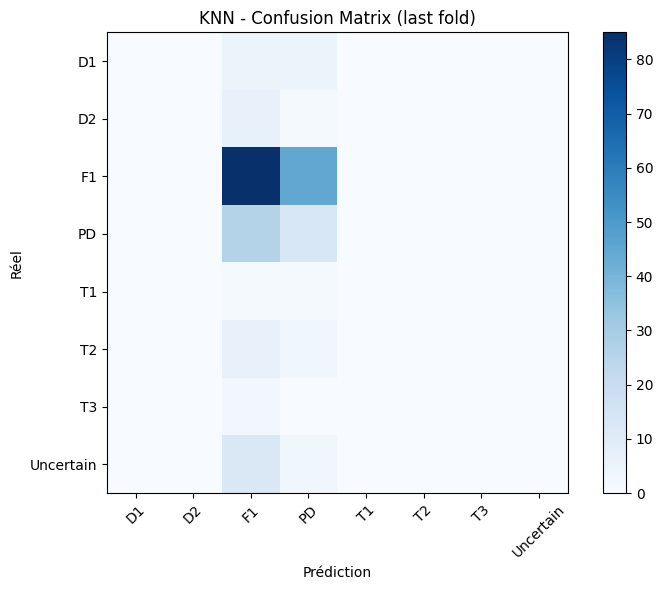


Classification report (fold 5):
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00        10
          D2       0.00      0.00      0.00         7
          F1       0.59      0.65      0.62       130
          PD       0.18      0.33      0.24        39
          T1       0.00      0.00      0.00         2
          T2       0.00      0.00      0.00         9
          T3       0.00      0.00      0.00         2
   Uncertain       0.00      0.00      0.00        15

    accuracy                           0.46       214
   macro avg       0.10      0.12      0.11       214
weighted avg       0.39      0.46      0.42       214


=== Résumé des performances ===
                     Accuracy mean  Precision macro  Recall macro  \
Logistic Regression         0.6336           0.0929        0.1452   
SVC                         0.6336           0.0929        0.1452   
Decision Tree               0.6336           0.0930        0.1452   
Random 

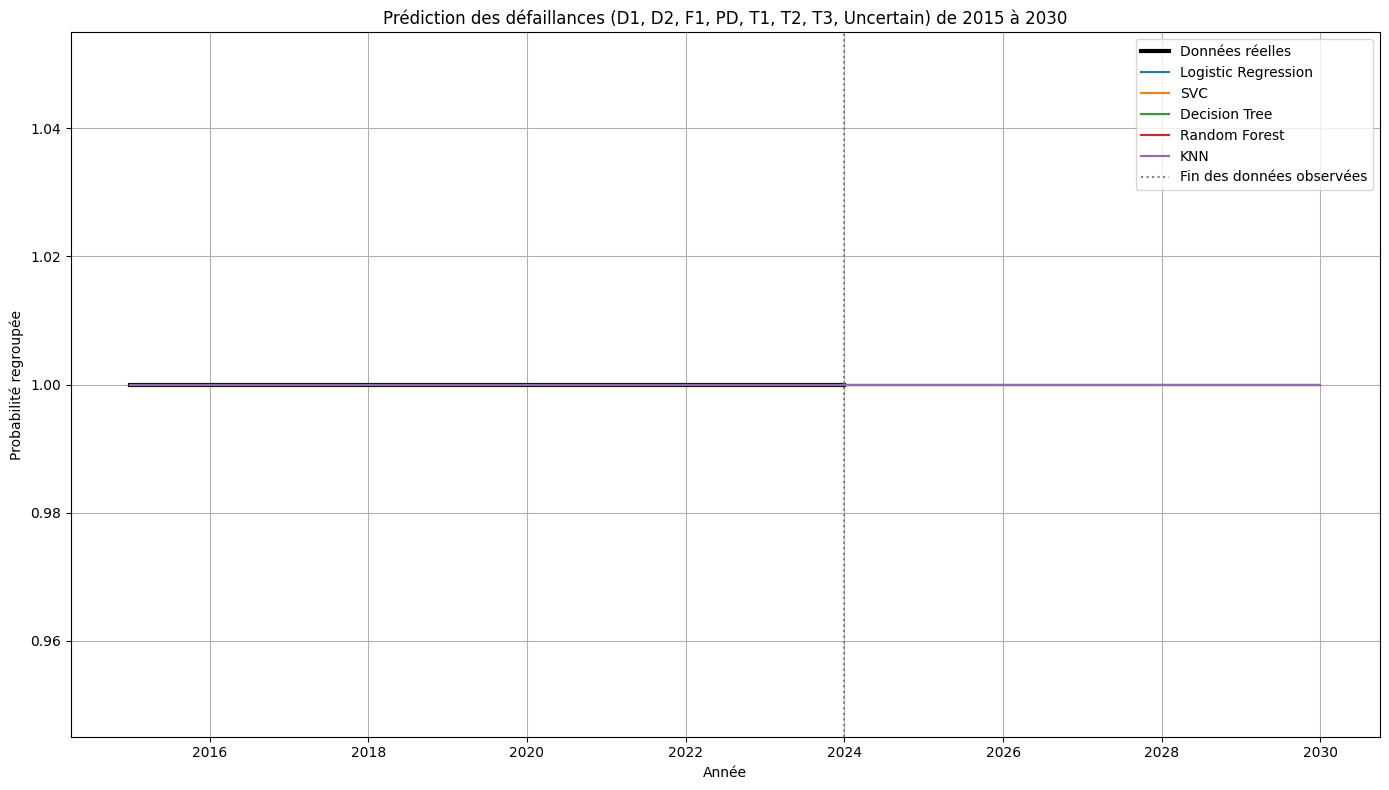

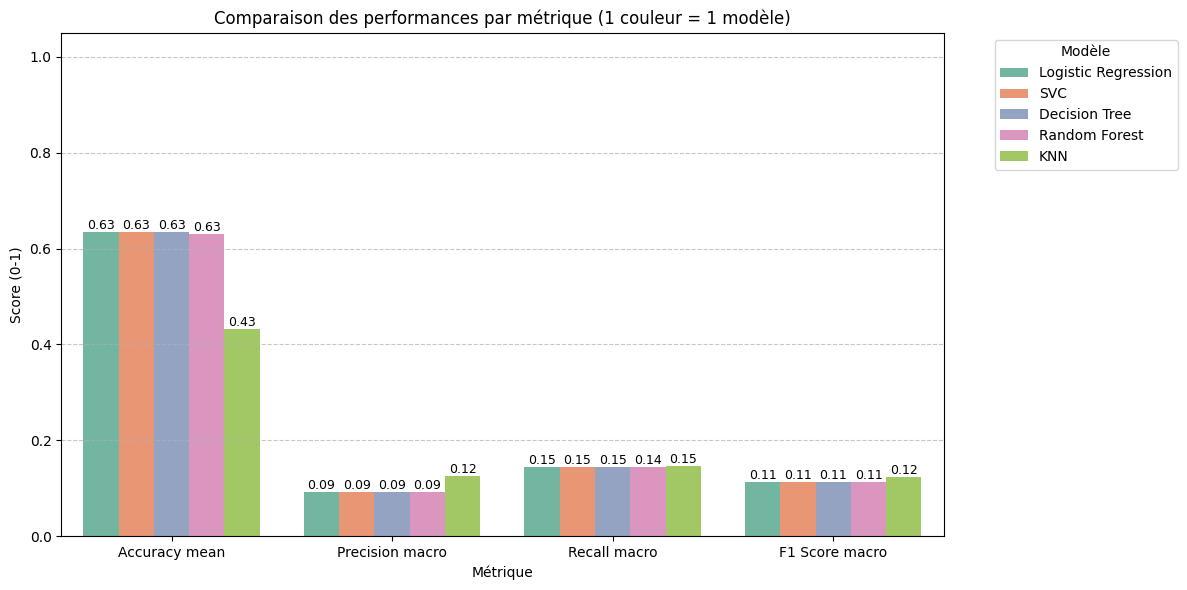

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# --- Préprocessing ---
df_clf = df[df["fault_majority_vote"] != "test"].copy()

label_encoder = LabelEncoder()
df_clf["fault_encoded"] = label_encoder.fit_transform(df_clf["fault_majority_vote"])
fault_labels = {i: c for i, c in enumerate(label_encoder.classes_)}

# --- Feature engineering ---
df_clf["year_num"] = df_clf["Year Test"] - df_clf["Year Test"].min()
df_clf["year_sin"] = np.sin(2 * np.pi * df_clf["Year Test"] / 12)
df_clf["year_cos"] = np.cos(2 * np.pi * df_clf["Year Test"] / 12)

X = df_clf[["year_num", "year_sin", "year_cos"]]
y = df_clf["fault_encoded"].values

# --- Modèles avec hyperparamètres optimaux ---
models = {
    "Logistic Regression": LogisticRegression(C=0.01, max_iter=1000),
    "SVC": SVC(C=0.1, gamma='scale', kernel='rbf', probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=1, min_samples_split=2, random_state=42),
    "Random Forest": RandomForestClassifier(max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7, p=1, weights='uniform')
}

# --- Validation croisée temporelle ---
tscv = TimeSeriesSplit(n_splits=5)
results = {}

for name, model in models.items():
    acc_scores, prec_scores, rec_scores, f1_scores, spec_scores = [], [], [], [], []

    print(f"\n=== {name} ===")

    for i, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        acc_scores.append(accuracy_score(y_val, y_pred))
        prec_scores.append(precision_score(y_val, y_pred, average='macro', zero_division=0))
        rec_scores.append(recall_score(y_val, y_pred, average='macro', zero_division=0))
        f1_scores.append(f1_score(y_val, y_pred, average='macro', zero_division=0))

        cm = confusion_matrix(y_val, y_pred, labels=np.arange(len(fault_labels)))
        spec = []
        for j in range(len(cm)):
            tn = cm.sum() - (cm[j, :].sum() + cm[:, j].sum() - cm[j, j])
            fp = cm[:, j].sum() - cm[j, j]
            spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        spec_scores.append(np.mean(spec))

        # Affichage matrice de confusion du dernier fold
        if i == tscv.get_n_splits() - 1:
            plt.figure(figsize=(8, 6))
            plt.imshow(cm, cmap="Blues", interpolation="nearest")
            plt.title(f"{name} - Confusion Matrix (last fold)")
            plt.colorbar()
            tick_marks = np.arange(len(fault_labels))
            plt.xticks(tick_marks, fault_labels.values(), rotation=45)
            plt.yticks(tick_marks, fault_labels.values())
            plt.xlabel("Prédiction")
            plt.ylabel("Réel")
            plt.tight_layout()
            plt.show()

        # Rapport classification avec toutes les classes
        print(f"\nClassification report (fold {i+1}):")
        print(classification_report(
            y_val,
            y_pred,
            labels=list(fault_labels.keys()),        # Correction ici
            target_names=list(fault_labels.values()),
            zero_division=0
        ))

    results[name] = {
        "Accuracy mean": np.mean(acc_scores),
        "Precision macro": np.mean(prec_scores),
        "Recall macro": np.mean(rec_scores),
        "F1 Score macro": np.mean(f1_scores),
        "Specificity macro": np.mean(spec_scores)
    }

# --- Résumé des performances ---
summary_df = pd.DataFrame(results).T.round(4)
print("\n=== Résumé des performances ===")
print(summary_df)

# --- Préparation pour tracé des prédictions futures ---
selected_faults_idx = list(range(len(fault_labels)))  # Ou ajuster selon classes "faults"
selected_faults_names = [fault_labels[i] for i in selected_faults_idx]

df_clf["is_selected_fault"] = df_clf["fault_encoded"].isin(selected_faults_idx).astype(int)
real_proportion = df_clf.groupby("Year Test")["is_selected_fault"].mean()

future_years = np.arange(df_clf["Year Test"].min(), 2031)
future_year_num = future_years - df_clf["Year Test"].min()
future_year_sin = np.sin(2 * np.pi * future_years / 12)
future_year_cos = np.cos(2 * np.pi * future_years / 12)
X_future = pd.DataFrame({
    "year_num": future_year_num,
    "year_sin": future_year_sin,
    "year_cos": future_year_cos
})

plt.figure(figsize=(14, 8))
plt.plot(real_proportion.index, real_proportion.values, label="Données réelles", linewidth=3, color="black")

for name, model in models.items():
    model.fit(X, y)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_future)
        grouped_proba = proba[:, selected_faults_idx].sum(axis=1)
    else:
        preds = model.predict(X_future)
        grouped_proba = np.isin(preds, selected_faults_idx).astype(int)

    plt.plot(future_years, grouped_proba, label=name)

plt.axvline(x=df_clf["Year Test"].max(), color="grey", linestyle=":", label="Fin des données observées")
plt.xlabel("Année")
plt.ylabel("Probabilité regroupée")
plt.title(f"Prédiction des défaillances ({', '.join(selected_faults_names)}) de {df_clf['Year Test'].min()} à 2030")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Graphe comparatif des métriques ---
metrics_to_plot = ["Accuracy mean", "Precision macro", "Recall macro", "F1 Score macro"]
df_plot = summary_df[metrics_to_plot].copy()
df_plot["Modèle"] = df_plot.index

df_melted = df_plot.melt(id_vars="Modèle", var_name="Métrique", value_name="Score")
palette = sns.color_palette("Set2", n_colors=df_plot["Modèle"].nunique())

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_melted,
    x="Métrique",
    y="Score",
    hue="Modèle",
    palette=palette
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9)

plt.title("Comparaison des performances par métrique (1 couleur = 1 modèle)")
plt.ylim(0, 1.05)
plt.ylabel("Score (0-1)")
plt.xlabel("Métrique")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Modèle", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 3. Models

### 3.1 Model Selection

We are testing several machine learning models:

* Logistic Regression
* SVM (Support Vector Machine)
* Decision Trees
* Random Forest
* K-Nearest Neighbors (KNN)

We will apply the same training method to the different models we are going to test and compare their performance.

### 3.2 Splitting the Dataset for Cross-Validation

We use 5-fold cross-validation with stratified sampling to evaluate model performance more reliably:
* The dataset is split into 5 distinct subsets of equal size.
* For each iteration, 80% of the data is used for training and the remaining 20% is used for testing, without overlap between test sets.
* This ensures that every data point is used exactly once for testing, allowing a more robust and generalized evaluation of the model.
* Stratified splitting ensures that each fold preserves the original class distribution, which is particularly important for imbalanced datasets.

In [5]:
# Setup time series cross-validation (important to avoid data leakage in time)
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

### 3.3 Model Evaluation Methodology

In this section, we implement a comparative analysis of several machine learning models to forecast Thailand’s monthly seafood export volume. The methodology consists of the following steps:

- **Data Preparation**:
We use cleaned and time-encoded data including a numerical time index and cyclical features (month sine and cosine) to capture seasonality.

- **Validation Strategy**:
A TimeSeriesSplit with 5 folds is used to respect the chronological order of the data during training and evaluation.

- **Performance Metrics**:
For each model and fold, we compute:

    - Root Mean Squared Error (RMSE)

    - R² Score (Coefficient of Determination)
Average and standard deviation values are calculated to assess both accuracy and consistency

- **Visualization**:

    - For the last fold of each model, a scatter plot is generated comparing actual vs. predicted values.

    - A final forecasting plot displays each model’s predicted export volume from the start of the dataset up to 2030, along with the actual historical data for comparison.

This approach allows us to identify which model best captures the trends and seasonal behavior in export quantities, while also testing their generalization capability beyond the observed data.

### 3.4 Applying the Models


--- Optimisation et évaluation des modèles sur les features classiques ---

Recherche d'hyperparamètres pour Random Forest (features classiques)...
Meilleurs hyperparamètres pour Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

Recherche d'hyperparamètres pour Naive Bayes (features classiques)...
Pas de grille d'hyperparamètres définie pour Naive Bayes. Utilisation des paramètres par défaut.

Recherche d'hyperparamètres pour KNN (features classiques)...
Meilleurs hyperparamètres pour KNN: {'n_neighbors': 3, 'weights': 'distance'}

Recherche d'hyperparamètres pour SVM (features classiques)...
Meilleurs hyperparamètres pour SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Recherche d'hyperparamètres pour Logistic Regression (features classiques)...
Meilleurs hyperparamètres pour Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

Recherche d'hyperparamètres pour Decision Tree (features classiques)...
Meilleurs hyperparamètres pour Deci

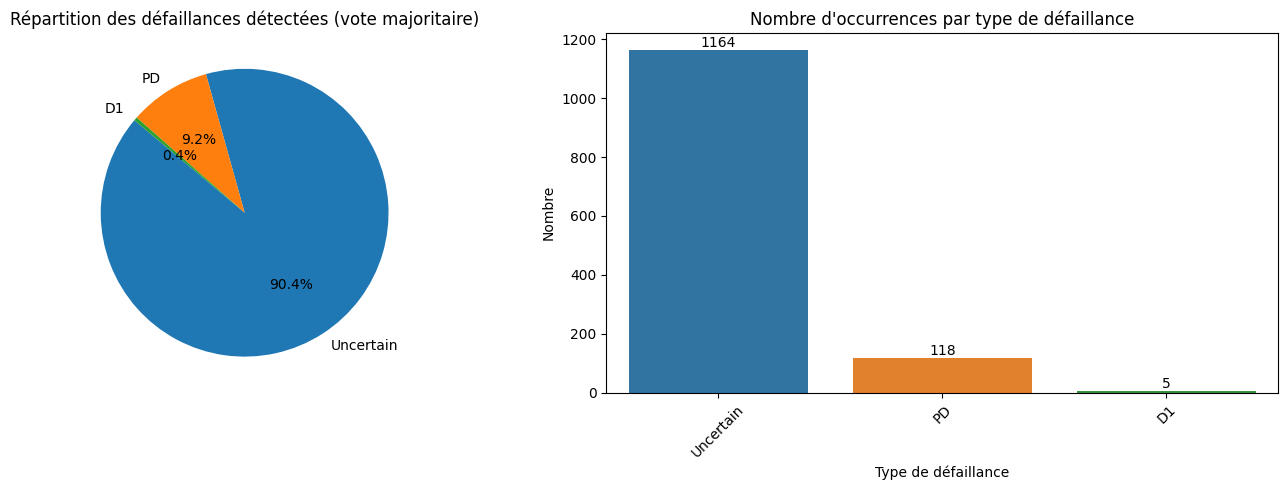

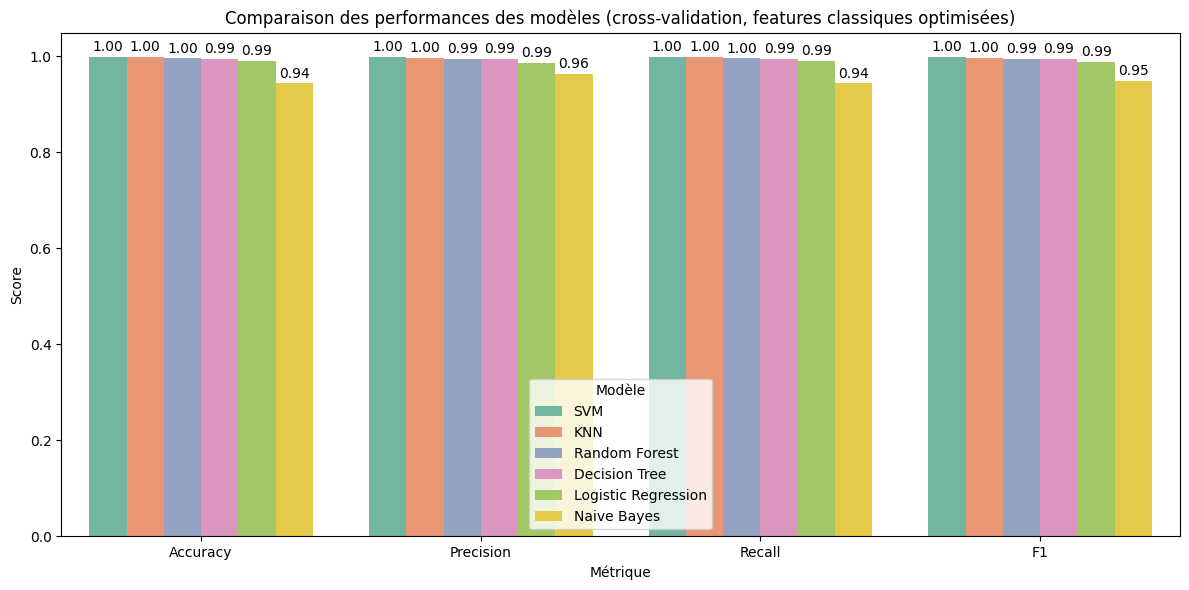

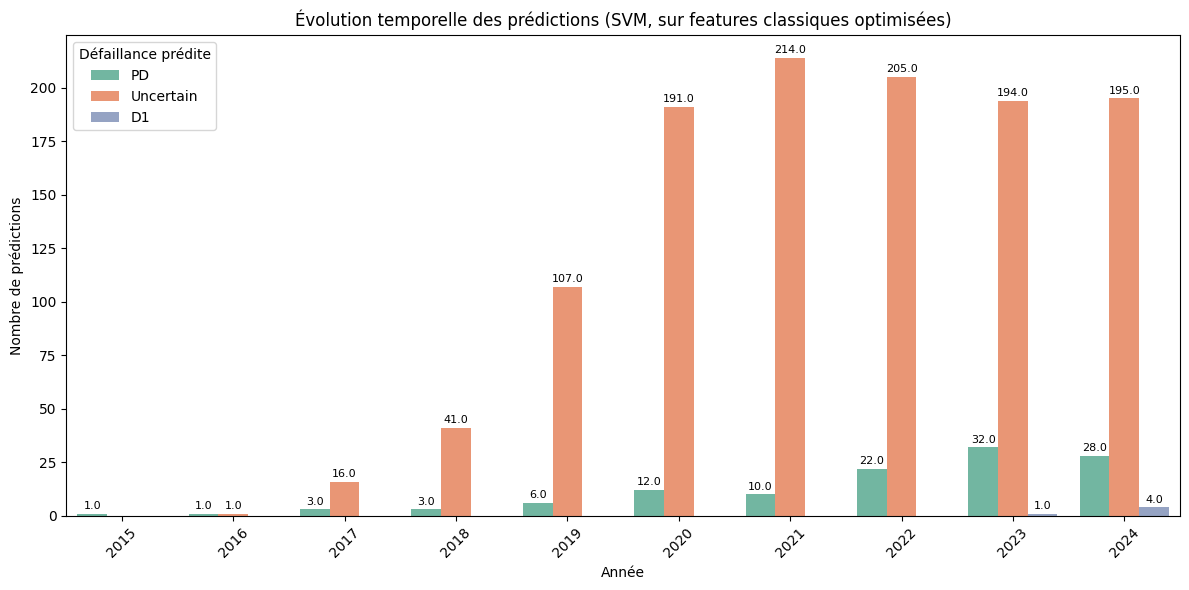

Impossible d'afficher l'importance des variables pour SVM.


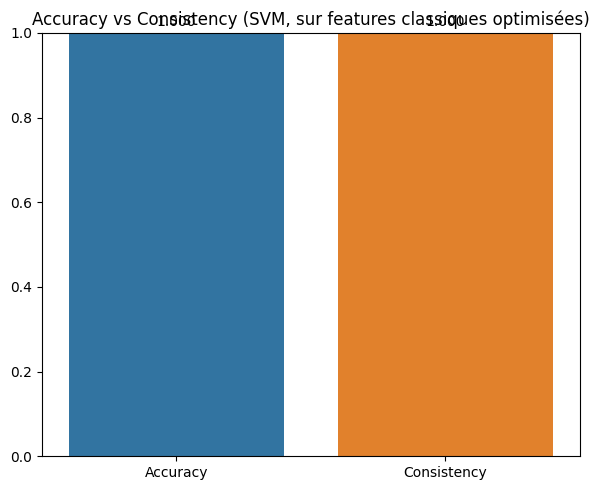


--- Optimisation et évaluation des modèles temporels ---

Recherche d'hyperparamètres pour Random Forest (features temporelles)...
Meilleurs hyperparamètres pour Random Forest: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Mean CV Accuracy   : 0.905 ± 0.036
Mean CV Precision  : 0.424
Mean CV Recall     : 0.466
Mean CV Specificity: 0.400
Mean CV F1-Score   : 0.444

Recherche d'hyperparamètres pour Naive Bayes (features temporelles)...
Pas de grille d'hyperparamètres définie pour Naive Bayes. Utilisation des paramètres par défaut.
Mean CV Accuracy   : 0.821 ± 0.082
Mean CV Precision  : 0.411
Mean CV Recall     : 0.390
Mean CV Specificity: 0.546
Mean CV F1-Score   : 0.396

Recherche d'hyperparamètres pour KNN (features temporelles)...
Meilleurs hyperparamètres pour KNN: {'n_neighbors': 7, 'weights': 'uniform'}
Mean CV Accuracy   : 0.906 ± 0.036
Mean CV Precision  : 0.424
Mean CV Recall     : 0.467
Mean CV Specificity: 0.400
Mean CV F1-Score   : 0.444

Recherche d'hyperpara

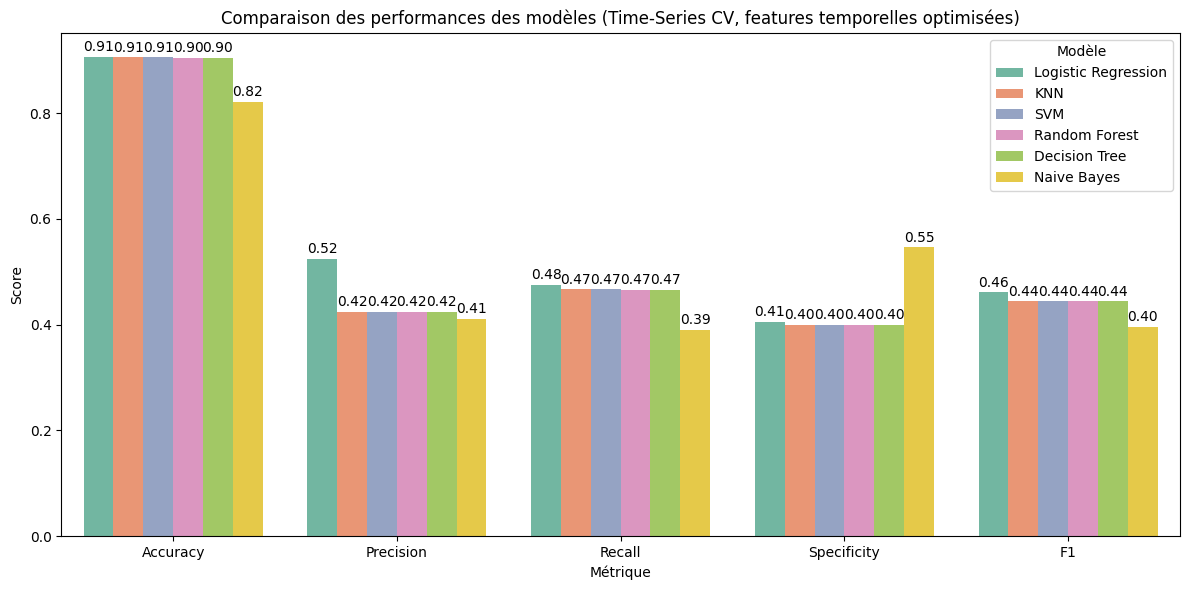


--- Génération du graphique de prédiction temporelle principale ---


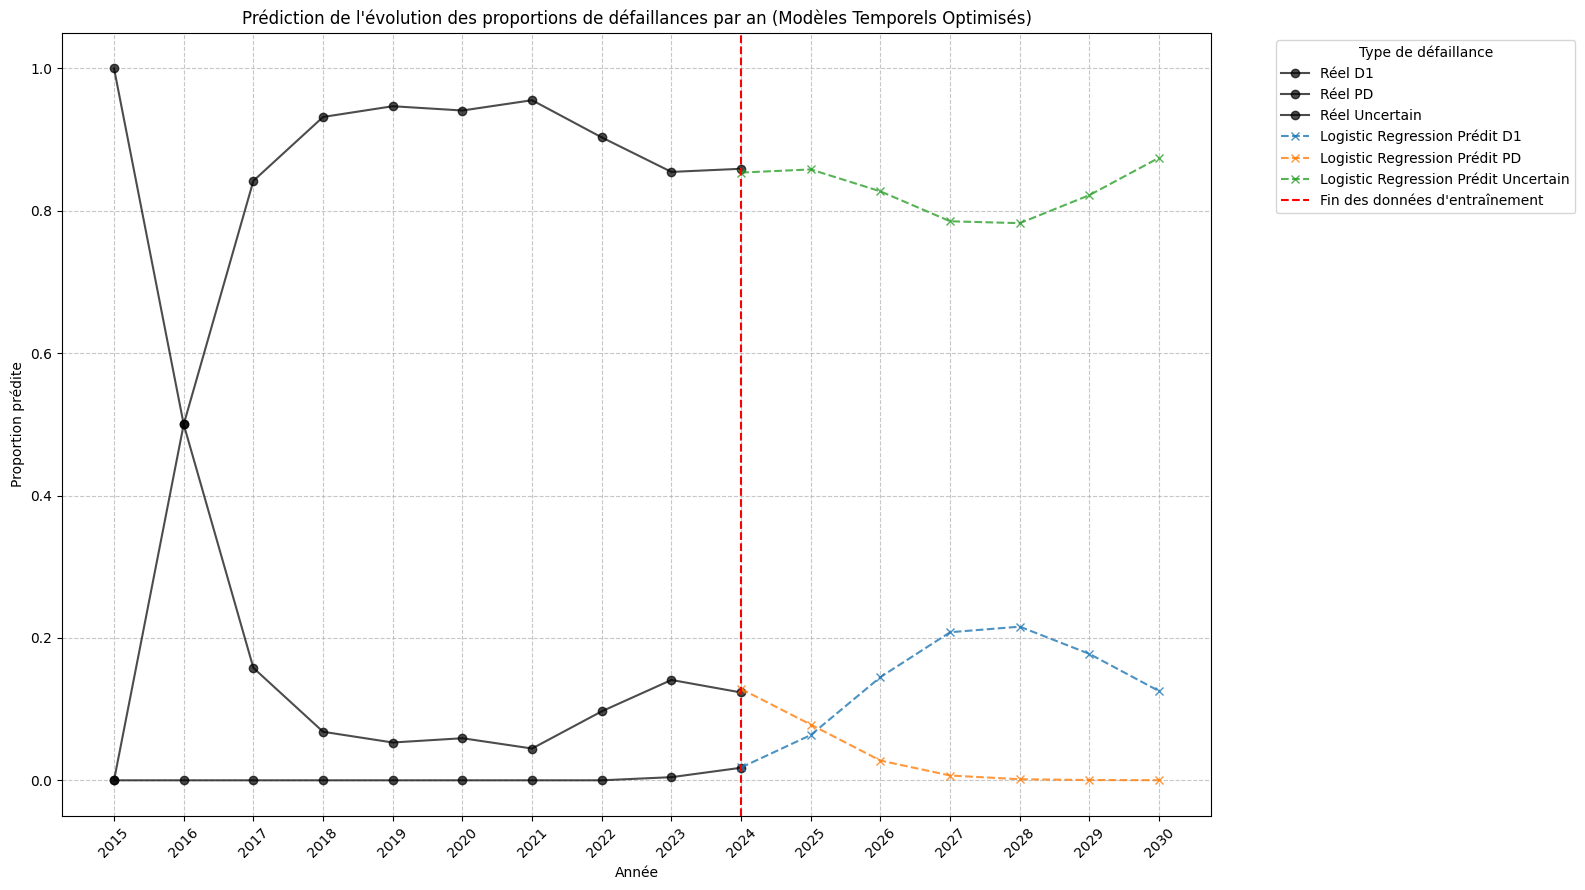


--- Génération des graphiques de prédiction temporelle par modèle (Optionnel) ---


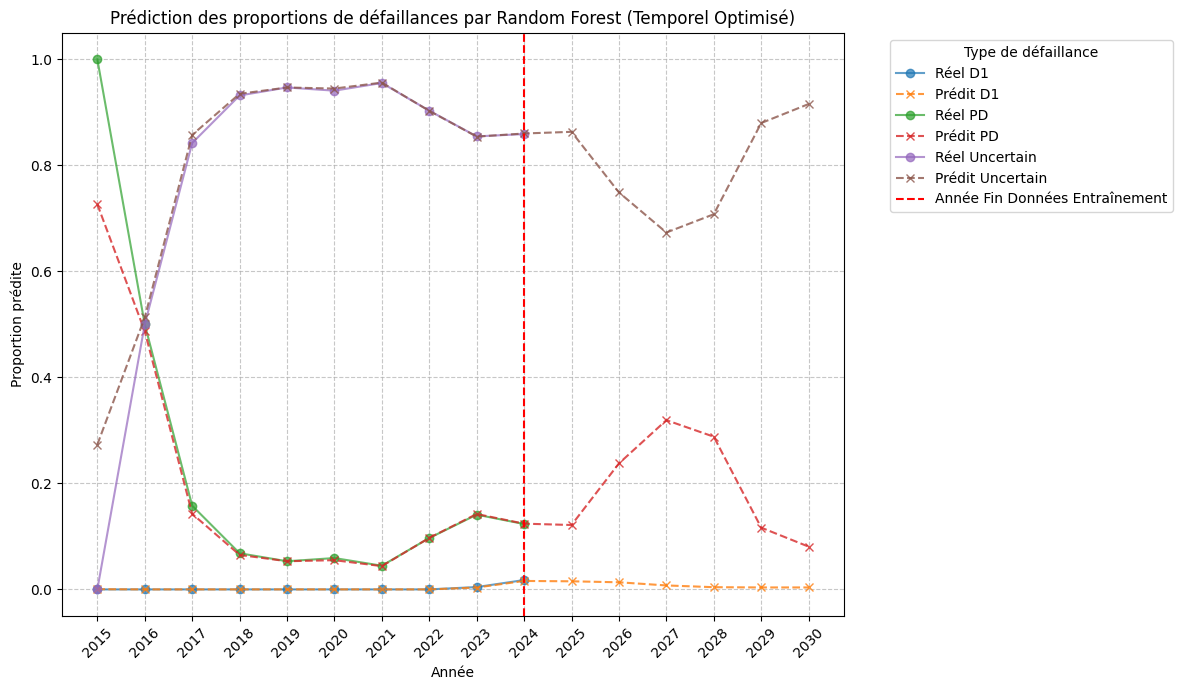

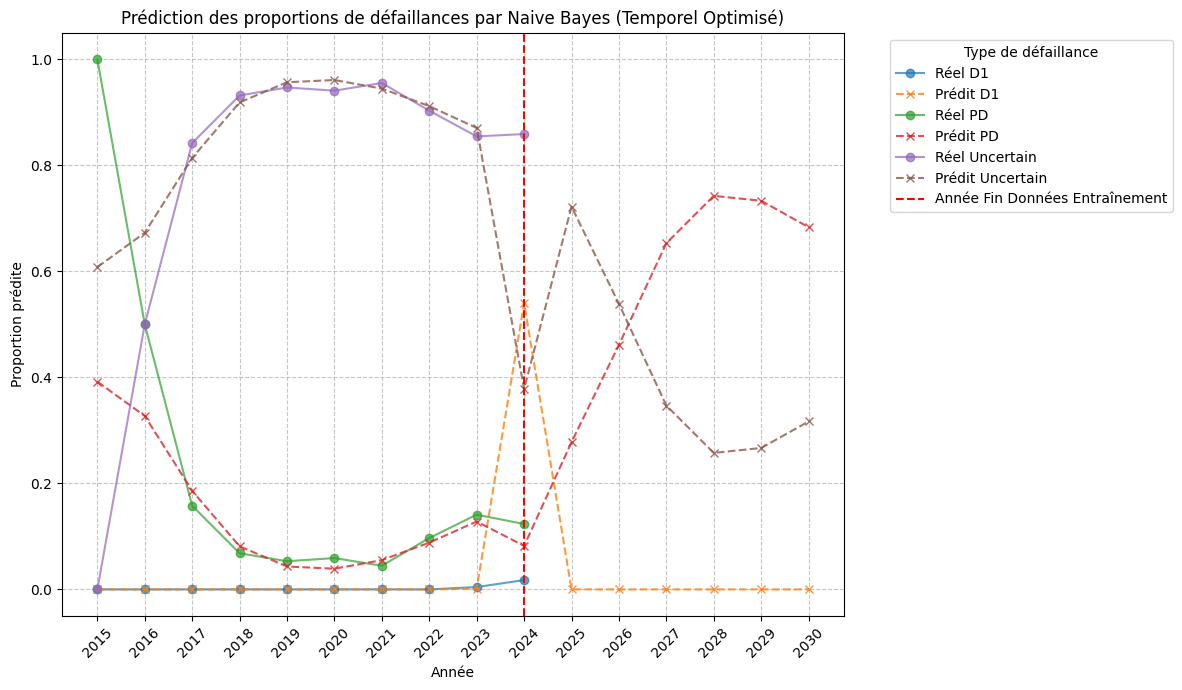

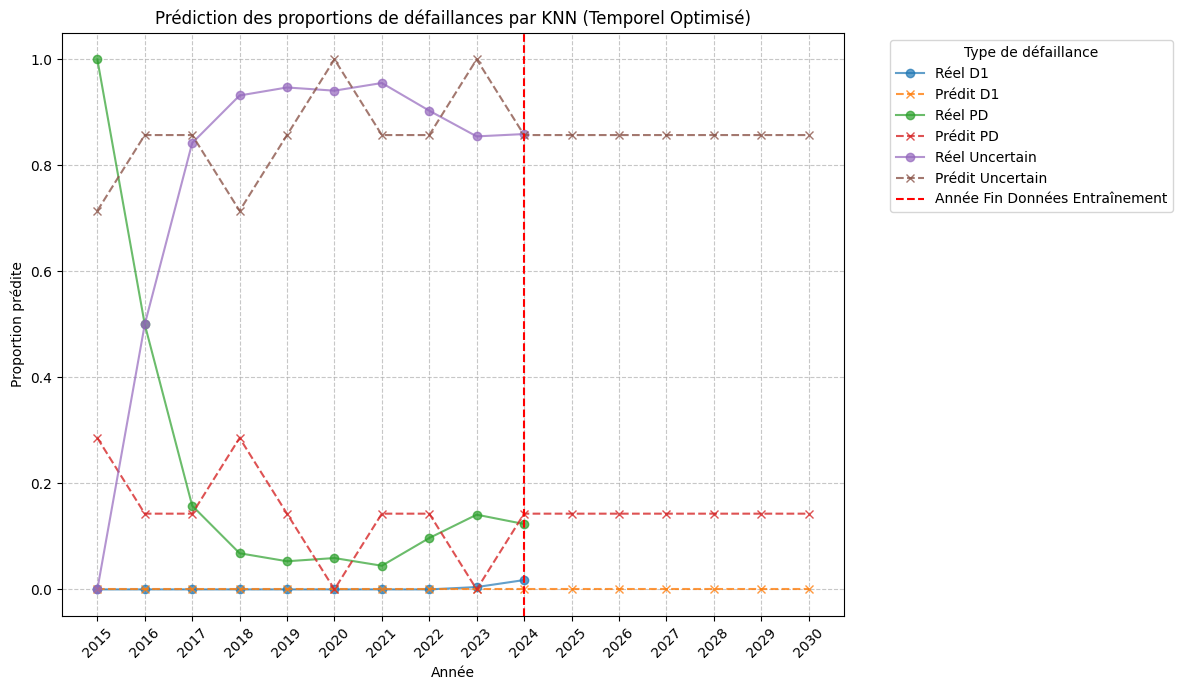

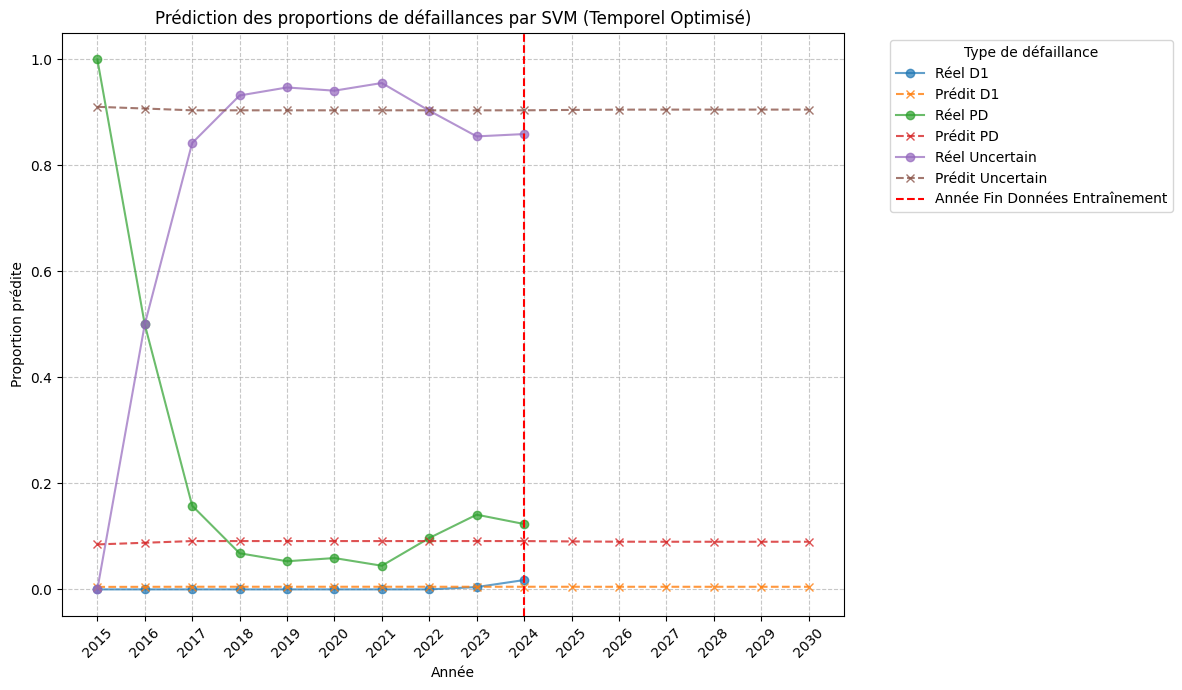

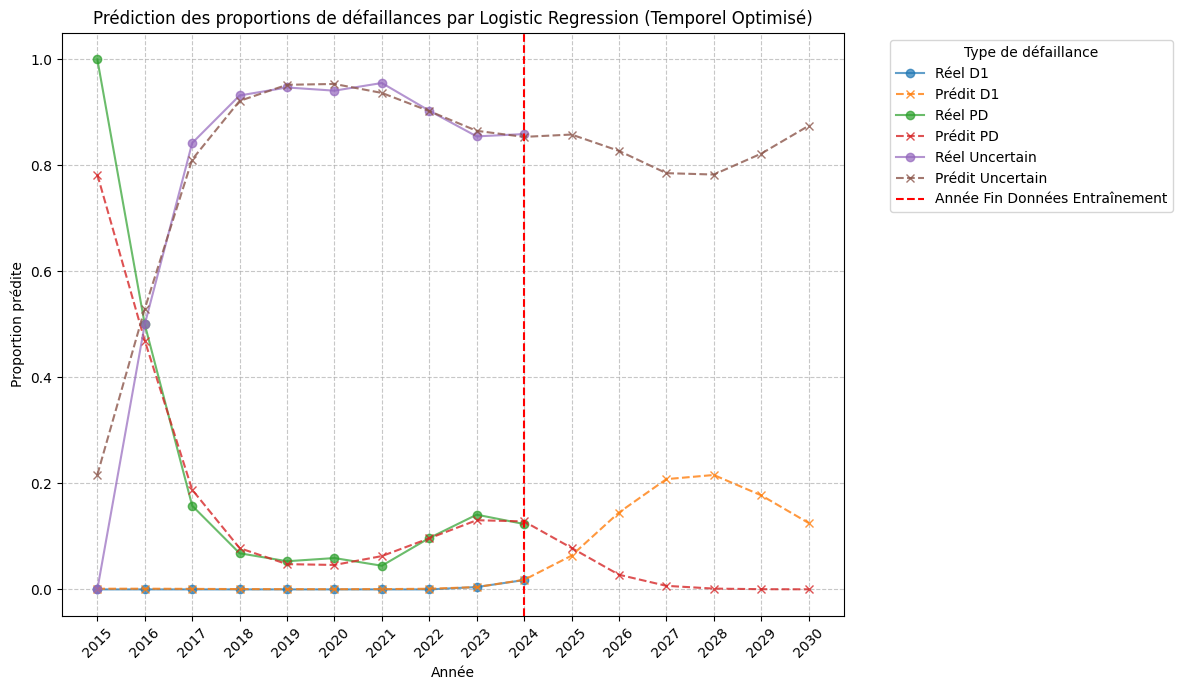

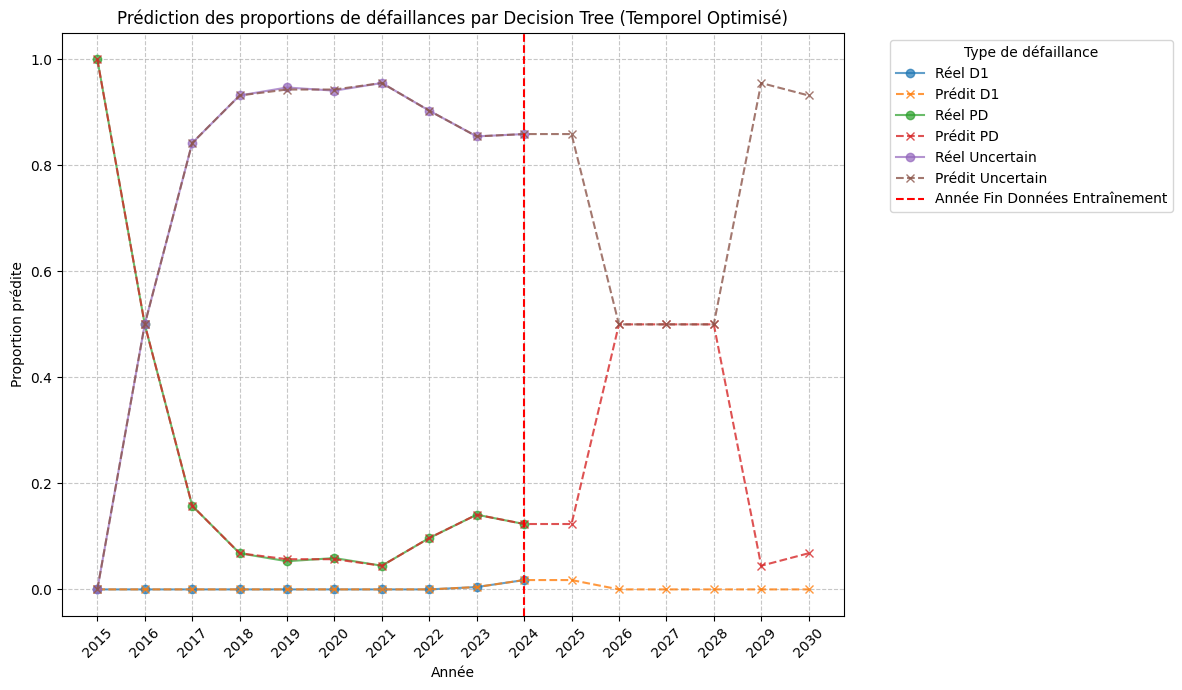


--- Script terminé ---


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignorer les avertissements pour une meilleure lisibilité de la sortie
warnings.filterwarnings('ignore')

# =========================================
# Étape 1 : Préparation et nettoyage des données
# =========================================
# Assurez-vous que le fichier 'DGA_Main_115kV.csv' est dans le dossier 'DATA/'
try:
    df = pd.read_csv("DATA/DGA_Main_115kV.csv")
except FileNotFoundError:
    print("Erreur: Le fichier 'DGA_Main_115kV.csv' n'a pas été trouvé dans le dossier 'DATA/'.")
    print("Veuillez vous assurer que le chemin est correct et que le fichier existe.")
    exit() # Quitte le script si le fichier n'est pas trouvé

df = df.drop(columns=["Unnamed: 20", "Unnamed: 21"], errors='ignore')
df = df.dropna(subset=["Year Test"])
df["Year Test"] = df["Year Test"].astype(int)

colonnes_a_verifier = [
    'MFG', 'KV', 'MVA', 'Age', 'Year Test', 'O2', 'N2', 'CO2', 'CO',
    'H2', 'CH4', 'C2H2', 'C2H4', 'C2H6', 'C3H6', 'C3H8', 'TCG', 'TEMP', 'WATER'
]
df = df[~df[colonnes_a_verifier].eq(0.0).all(axis=1)]
df["year_num"] = df["Year Test"] - df["Year Test"].min() # Utilisé pour les features temporelles

# Ratios
for ratio, num, denom in zip(["R1", "R2", "R3", "R4", "R5"], ["CH4", "C2H2", "C2H2", "C2H6", "C2H4"], ["H2", "C2H4", "CH4", "C2H2", "C2H6"]):
    df[ratio] = df[num] / df[denom].replace(0, np.nan)
df["Duval_Total"] = df[["CH4", "C2H2", "C2H4"]].sum(axis=1).replace(0, np.nan)

# =========================================
# Étape 2 : Méthodes de classification classiques
# =========================================
def classify_IRM(row):
    R1, R2, R5 = row["R1"], row["R2"], row["R5"]
    if pd.isna(R1) or pd.isna(R2) or pd.isna(R5): return "Uncertain"
    if R1 < 0.1 and R5 < 0.2: return "PD"
    elif R1 < 0.1 and R2 > 1 and R5 > 1: return "PD"
    elif 0.1 <= R1 <= 1 and 0.6 <= R2 <= 2.5 and R5 > 2: return "D1"
    elif R5 < 1: return "F1"
    elif R1 > 1 and R2 < 0.1 and 1 <= R5 <= 4: return "T2"
    elif R1 > 1 and R2 < 0.2 and R5 > 4: return "T3"
    else: return "Uncertain"

def classify_DRM(row):
    if pd.isna(row["R1"]) or pd.isna(row["R2"]) or pd.isna(row["R3"]) or pd.isna(row["R4"]): return "Uncertain"
    if not (row["H2"] > 100 and (row["CH4"] > 120 or row["C2H2"] > 1 or row["C2H4"] > 50)): return "Uncertain"
    R1, R2, R3, R4 = row["R1"], row["R2"], row["R3"], row["R4"]
    if R1 > 1 and R2 < 0.75 and R3 < 0.3 and R4 > 0.4: return "F1"
    elif R1 < 0.1 and R3 < 0.3 and R4 > 0.4: return "PD"
    elif 0.1 <= R1 <= 1 and R2 > 0.75 and R3 < 0.3 and R4 < 0.4: return "D2"
    else: return "Uncertain"

def classify_RRM(row):
    if pd.isna(row["R1"]) or pd.isna(row["R2"]) or pd.isna(row["R5"]): return "Uncertain"
    if row[["CH4", "H2", "C2H2", "C2H4", "C2H6"]].min() <= 0: return "Uncertain"
    R1, R2, R5 = row["R1"], row["R2"], row["R5"]
    if 0.1 <= R1 <= 1 and R2 < 0.1 and R5 < 1: return "F1"
    elif R1 < 0.1 and R2 < 0.1 and R5 < 1: return "PD"
    elif 0.1 <= R1 <= 1 and 0.1 <= R2 <= 3 and R5 > 3: return "D2"
    elif 0.1 <= R1 <= 1 and R2 < 0.1 and 1 <= R5 <= 3: return "T1"
    elif R1 > 1 and R2 < 0.1 and 1 <= R5 <= 3: return "T2"
    elif R1 > 1 and R2 < 0.1 and R5 > 3: return "T3"
    else: return "Uncertain"

def classify_DTM(row):
    ch4, c2h2, c2h4 = row["CH4"], row["C2H2"], row["C2H4"]
    total = ch4 + c2h2 + c2h4
    if total == 0: return "Uncertain"
    pct_ch4 = 100 * ch4 / total
    pct_c2h2 = 100 * c2h2 / total
    pct_c2h4 = 100 * c2h4 / total
    if pct_c2h2 > 23 and pct_c2h4 < 40: return "PD"
    elif pct_c2h4 > 40 and pct_c2h2 < 23: return "T2"
    elif 23 <= pct_c2h2 <= 50 and 20 <= pct_c2h4 <= 50: return "D1"
    elif pct_c2h4 < 20 and pct_c2h2 < 23: return "T1"
    else: return "Uncertain"

def classify_DPM(row):
    gases = ["CH4", "C2H2", "C2H4", "H2", "C2H6"]
    total = row[gases].sum()
    if total == 0: return "Uncertain"
    pct_ch4 = 100 * row["CH4"] / total
    pct_c2h2 = 100 * row["C2H2"] / total
    pct_c2h4 = 100 * row["C2H4"] / total
    pct_h2 = 100 * row["H2"] / total
    pct_c2h6 = 100 * row["C2H6"] / total
    if pct_c2h2 > 20 and pct_h2 > 15: return "PD"
    elif pct_c2h4 > 40 and pct_c2h6 < 10: return "T1"
    elif pct_c2h6 > 10 and pct_ch4 > 15: return "T3"
    else: return "Uncertain"

for name, func in zip(["IRM", "DRM", "RRM", "DTM", "DPM"], [classify_IRM, classify_DRM, classify_RRM, classify_DTM, classify_DPM]):
    df[f"{name}_fault"] = df.apply(func, axis=1)

# =========================================
# Étape 3 : Calcul coordonnées Duval (Cx, Cy)
# =========================================
gases = ["CH4", "C2H2", "C2H4", "H2", "C2H6"]
df["Total_DP"] = df[gases].sum(axis=1)
df = df[df["Total_DP"] > 0]
for g in gases:
    df[f"%{g}"] = 100 * df[g] / df["Total_DP"]
df["Cx"] = (df["%CH4"] + 0.5 * df["%C2H6"] - 0.5 * df["%C2H2"] - df["%C2H4"]) / 100
df["Cy"] = (0.866 * df["%C2H6"] + 0.866 * df["%C2H2"]) / 100

# =========================================
# Étape 4 : Encodage et préparation cible
# =========================================
method_columns = ["IRM_fault", "DRM_fault", "RRM_fault", "DTM_fault", "DPM_fault"]
for col in method_columns:
    df[f"{col}_enc"] = LabelEncoder().fit_transform(df[col])

df["true_fault"] = df[method_columns].mode(axis=1)[0]
le_target = LabelEncoder()
df["true_fault_index"] = le_target.fit_transform(df["true_fault"])

# Convertir les index des classes en labels pour référence
fault_labels = {i: c for i, c in enumerate(le_target.classes_)}


# =========================================
# Préparation des données pour la prédiction temporelle
# =========================================

# Caractéristiques temporelles
df["year_sin"] = np.sin(2 * np.pi * df["Year Test"] / 12)
df["year_cos"] = np.cos(2 * np.pi * df["Year Test"] / 12)

# Les caractéristiques pour les modèles de prédiction temporelle seront uniquement les features temporelles
X_temporal = df[["year_num", "year_sin", "year_cos"]]
y_temporal = df["true_fault_index"].values

# Années futures pour la prédiction
future_years = np.arange(df["Year Test"].min(), 2031)
future_year_num = future_years - df["Year Test"].min()
future_year_sin = np.sin(2 * np.pi * future_years / 12)
future_year_cos = np.cos(2 * np.pi * future_years / 12)

X_future_temporal = pd.DataFrame({
    "year_num": future_year_num,
    "year_sin": future_year_sin,
    "year_cos": future_year_cos
})

# Obtenir les proportions réelles pour le plotting
real_proportions_by_year = df.groupby("Year Test")["true_fault_index"].value_counts(normalize=True).unstack(fill_value=0)
# Renommer les colonnes pour qu'elles correspondent aux labels originaux
real_proportions_by_year.columns = [fault_labels[idx] for idx in real_proportions_by_year.columns]

# =========================================
# Définition des modèles et de leurs hyperparamètres pour GridSearchCV
# =========================================

# Grilles d'hyperparamètres pour les modèles
param_grids = {
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    },
    "Naive Bayes": {
        # GaussianNB n'a pas d'hyperparamètres majeurs à ajuster via GridSearchCV
        # On pourrait tester 'var_smoothing' mais souvent pas nécessaire pour des gains importants
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    "Logistic Regression": {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l2']
    },
    "Decision Tree": {
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
        'criterion': ['gini', 'entropy']
    }
}

# Initialisation des modèles pour l'évaluation avec les meilleurs hyperparamètres
models_to_evaluate = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}


# Fonction d'évaluation des métriques (identique)
def evaluate_model_metrics(y_true, y_pred, average='macro'):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    specificity_per_class = []
    num_classes = len(fault_labels)

    for i in range(num_classes):
        # Vérifie si la classe 'i' est présente dans la matrice de confusion calculée pour ce fold
        # La matrice de confusion peut être plus petite si toutes les classes ne sont pas présentes dans le fold.
        if i < cm.shape[0] and i < cm.shape[1]:
            TP = cm[i, i]
            FN = cm[i, :].sum() - TP
            FP = cm[:, i].sum() - TP
            TN = cm.sum() - (TP + FN + FP)
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        else:
            specificity = 0 # Si la classe n'est pas dans le fold, sa spécificité est considérée comme 0 pour cette moyenne
        specificity_per_class.append(specificity)
    specificity = np.mean(specificity_per_class)

    return acc, prec, rec, specificity, f1

# =========================================
# Modélisation et évaluation (sur features classiques avec GridSearchCV)
# =========================================

print("\n--- Optimisation et évaluation des modèles sur les features classiques ---")

cv_initial = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_initial = {}
best_initial_models = {} # Pour stocker les meilleurs modèles entraînés avec les hyperparamètres optimaux

X_initial = df[[f"{col}_enc" for col in method_columns] + ["Cx", "Cy"]]
y_initial = df["true_fault_index"]

# Appliquer la mise à l'échelle pour les modèles sensibles
scaler_initial = StandardScaler()
# Scaler seulement si X_initial n'est pas vide
if not X_initial.empty:
    X_initial_scaled = scaler_initial.fit_transform(X_initial)
    X_initial_scaled_df = pd.DataFrame(X_initial_scaled, columns=X_initial.columns, index=X_initial.index)
else:
    X_initial_scaled_df = X_initial # Garde un DataFrame vide si initialement vide

for name, model_instance in models_to_evaluate.items():
    print(f"\nRecherche d'hyperparamètres pour {name} (features classiques)...")
    
    # Utiliser les données mises à l'échelle si le modèle est sensible
    X_data_for_grid = X_initial_scaled_df if name in ["SVM", "Logistic Regression", "KNN"] else X_initial

    if name in param_grids and param_grids[name]:
        grid_search = GridSearchCV(
            estimator=model_instance,
            param_grid=param_grids[name],
            cv=cv_initial,
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
        try:
            # Vérifier si l'ensemble de données est suffisamment grand pour GridSearchCV
            if len(X_data_for_grid) > 0 and len(np.unique(y_initial)) > 1:
                grid_search.fit(X_data_for_grid, y_initial)
                best_model = grid_search.best_estimator_
                best_params = grid_search.best_params_
                print(f"Meilleurs hyperparamètres pour {name}: {best_params}")
            else:
                raise ValueError("Données insuffisantes ou trop peu de classes pour GridSearchCV.")
        except ValueError as e:
            print(f"Erreur lors de GridSearchCV pour {name}: {e}. Utilisation des paramètres par défaut.")
            best_model = model_instance
            best_params = "N/A (Erreur GridSearchCV / paramètres par défaut)"
    else:
        best_model = model_instance
        best_params = "N/A (paramètres par défaut)"
        print(f"Pas de grille d'hyperparamètres définie pour {name}. Utilisation des paramètres par défaut.")
    
    best_initial_models[name] = best_model # Stocker le modèle optimisé

    # Évaluer le modèle avec les meilleurs hyperparamètres via cross_val_score
    if len(X_data_for_grid) > 0 and len(np.unique(y_initial)) > 1:
        acc = cross_val_score(best_model, X_data_for_grid, y_initial, cv=cv_initial, scoring='accuracy').mean()
        prec = cross_val_score(best_model, X_data_for_grid, y_initial, cv=cv_initial, scoring='precision_weighted').mean()
        rec = cross_val_score(best_model, X_data_for_grid, y_initial, cv=cv_initial, scoring='recall_weighted').mean()
        f1 = cross_val_score(best_model, X_data_for_grid, y_initial, cv=cv_initial, scoring='f1_weighted').mean()

        results_initial[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "Best Params": best_params}
    else:
        print(f"Données insuffisantes pour évaluer le modèle {name} avec cross_val_score.")
        results_initial[name] = {
            "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan,
            "F1": np.nan, "Best Params": best_params
        }


metrics_df_initial = pd.DataFrame(results_initial).T.round(3)
metrics_df_initial.sort_values("Accuracy", ascending=False, inplace=True)
print("\n--- Performances des modèles sur features classiques (avec hyperparamètres optimisés) ---")
print(metrics_df_initial)


# --- Vérification du surapprentissage pour les modèles classiques optimisés ---
print("\n--- Vérification du surapprentissage pour les modèles classiques optimisés ---")
for name, best_model in best_initial_models.items():
    X_data_for_pred = X_initial_scaled_df if name in ["SVM", "Logistic Regression", "KNN"] else X_initial
    
    if not X_data_for_pred.empty and len(np.unique(y_initial)) >= 2:
        try:
            best_model.fit(X_data_for_pred, y_initial)
            y_pred_train = best_model.predict(X_data_for_pred)
            train_accuracy = accuracy_score(y_initial, y_pred_train)
            
            # Récupérer l'accuracy moyenne de validation croisée déjà calculée
            cv_accuracy = results_initial[name]['Accuracy']
            
            print(f"\nModèle: {name}")
            print(f"  Accuracy sur l'ensemble d'entraînement (données vues): {train_accuracy:.3f}")
            print(f"  Accuracy moyenne de CV (données non vues): {cv_accuracy:.3f}")
            
            # Un seuil de 5% est un bon point de départ, mais peut être ajusté.
            if not pd.isna(cv_accuracy) and train_accuracy > cv_accuracy + 0.05:
                print("  --> Potentiel surapprentissage détecté : La performance sur les données d'entraînement est significativement plus élevée.")
            else:
                print("  --> Pas de signe majeur de surapprentissage (performance sur l'entraînement et CV sont proches).")
        except Exception as e:
            print(f"\nModèle: {name} - Erreur lors de la vérification du surapprentissage: {e}")
    else:
        print(f"\nModèle: {name} - Données insuffisantes ou trop peu de classes pour vérifier le surapprentissage.")


# =========================================
# Visualisations des données et des performances initiales (mises à jour)
# =========================================

print("\n--- Génération des visualisations des données et performances initiales ---")

# Répartition des fautes (pie + barres)
fault_counts = df["true_fault"].value_counts()
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].pie(fault_counts, labels=fault_counts.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title("Répartition des défaillances détectées (vote majoritaire)")
sns.barplot(x=fault_counts.index, y=fault_counts.values, ax=axs[1], palette="tab10")
axs[1].set_title("Nombre d'occurrences par type de défaillance")
axs[1].set_ylabel("Nombre")
axs[1].set_xlabel("Type de défaillance")
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45)
for i, v in enumerate(fault_counts.values):
    axs[1].text(i, v + 1, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Comparaison des modèles (sur features classiques avec hyperparamètres optimisés)
fig, ax = plt.subplots(figsize=(12, 6))
barplot = sns.barplot(
    data=metrics_df_initial.reset_index().melt(id_vars="index").loc[lambda df_melt: df_melt['variable'] != 'Best Params'], # Exclure la colonne Best Params
    x="variable", y="value", hue="index", palette="Set2"
)
for container in barplot.containers:
    barplot.bar_label(container, fmt="%.2f", label_type="edge", padding=2)
plt.title("Comparaison des performances des modèles (cross-validation, features classiques optimisées)")
plt.ylabel("Score")
plt.xlabel("Métrique")
plt.legend(title="Modèle")
plt.tight_layout()
plt.show()

# Prédictions du meilleur modèle initial dans le temps (sur données d'entraînement)
best_initial_model_name_for_plot = metrics_df_initial.index[0] if not metrics_df_initial.empty else None

if best_initial_model_name_for_plot and best_initial_model_name_for_plot in best_initial_models:
    best_initial_classifier = best_initial_models[best_initial_model_name_for_plot]
    X_data_for_pred = X_initial_scaled_df if best_initial_model_name_for_plot in ["SVM", "Logistic Regression", "KNN"] else X_initial
    
    if not X_data_for_pred.empty and len(np.unique(y_initial)) >= 2:
        best_initial_classifier.fit(X_data_for_pred, y_initial)
        df["Pred_Initial_Label"] = le_target.inverse_transform(best_initial_classifier.predict(X_data_for_pred))
        plt.figure(figsize=(12, 6))
        ax = sns.countplot(x="Year Test", hue="Pred_Initial_Label", data=df, palette="Set2")
        plt.title(f"Évolution temporelle des prédictions ({best_initial_model_name_for_plot}, sur features classiques optimisées)")
        plt.xlabel("Année")
        plt.ylabel("Nombre de prédictions")
        plt.xticks(rotation=45)
        plt.legend(title="Défaillance prédite")
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                                        ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 2),
                                        textcoords='offset points')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Données insuffisantes pour tracer l'évolution temporelle des prédictions pour {best_initial_model_name_for_plot}.")
else:
    print("Aucun modèle initial optimal n'a été trouvé pour le tracé de l'évolution temporelle des prédictions.")

# Importance des variables (pour le meilleur modèle initial, si applicable)
if best_initial_model_name_for_plot and best_initial_model_name_for_plot in best_initial_models:
    best_initial_classifier = best_initial_models[best_initial_model_name_for_plot]
    if hasattr(best_initial_classifier, 'feature_importances_'):
        importances_initial = best_initial_classifier.feature_importances_
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x=importances_initial, y=X_initial.columns, palette="viridis")
        plt.title(f"Importance des variables ({best_initial_model_name_for_plot}, sur features classiques optimisées)")
        plt.xlabel("Importance")
        for i, v in enumerate(importances_initial):
            ax.text(v + 0.001, i, f"{v:.3f}", color='black', va='center')
        plt.tight_layout()
        plt.show()
    elif hasattr(best_initial_classifier, 'coef_'):
        if best_initial_classifier.coef_.ndim > 1: # Multi-classe
            coef_abs = np.mean(np.abs(best_initial_classifier.coef_), axis=0)
        else: # Binaire
            coef_abs = np.abs(best_initial_classifier.coef_)

        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x=coef_abs, y=X_initial.columns, palette="viridis")
        plt.title(f"Importance des variables (Coefficients absolus pour {best_initial_model_name_for_plot}, features classiques optimisées)")
        plt.xlabel("Valeur absolue du coefficient")
        for i, v in enumerate(coef_abs):
            ax.text(v + 0.001, i, f"{v:.3f}", color='black', va='center')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Impossible d'afficher l'importance des variables pour {best_initial_model_name_for_plot}.")
else:
    print("Aucun modèle initial optimal n'a été trouvé pour le tracé de l'importance des variables.")

# Accuracy vs Consistency (du meilleur modèle initial)
if best_initial_model_name_for_plot and best_initial_model_name_for_plot in best_initial_models:
    best_initial_classifier = best_initial_models[best_initial_model_name_for_plot]
    X_data_for_pred = X_initial_scaled_df if best_initial_model_name_for_plot in ["SVM", "Logistic Regression", "KNN"] else X_initial
    
    if not X_data_for_pred.empty and len(np.unique(y_initial)) >= 2:
        accuracy_val = accuracy_score(y_initial, best_initial_classifier.predict(X_data_for_pred))
        consistency_val = (best_initial_classifier.predict(X_data_for_pred) == y_initial).sum() / len(y_initial)
        plt.figure(figsize=(6, 5))
        ax = sns.barplot(x=["Accuracy", "Consistency"], y=[accuracy_val, consistency_val], palette=["#1f77b4", "#ff7f0e"])
        plt.title(f"Accuracy vs Consistency ({best_initial_model_name_for_plot}, sur features classiques optimisées)")
        for i, val in enumerate([accuracy_val, consistency_val]):
            ax.text(i, val + 0.01, f"{val:.3f}", ha='center', va='bottom')
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Données insuffisantes pour tracer Accuracy vs Consistency pour {best_initial_model_name_for_plot}.")
else:
    print("Aucun modèle initial optimal n'a été trouvé pour le tracé Accuracy vs Consistency.")


# =========================================
# Implémentation de la prédiction temporelle avec modèles ML (avec GridSearchCV)
# =========================================

print("\n--- Optimisation et évaluation des modèles temporels ---")

# Normalisation des features temporelles
scaler_temporal = StandardScaler()
if not X_temporal.empty:
    X_temporal_scaled = scaler_temporal.fit_transform(X_temporal)
    X_temporal_scaled_df = pd.DataFrame(X_temporal_scaled, columns=X_temporal.columns, index=X_temporal.index)
else:
    X_temporal_scaled_df = X_temporal

tscv = TimeSeriesSplit(n_splits=5)
results_temporal = {}
all_model_predictions = {}
best_temporal_models = {} # Pour stocker les meilleurs modèles temporels entraînés

for name, model_instance in models_to_evaluate.items():
    print(f"\nRecherche d'hyperparamètres pour {name} (features temporelles)...")
    
    # Utiliser les données mises à l'échelle si le modèle est sensible
    X_data_for_grid = X_temporal_scaled_df if name in ["SVM", "Logistic Regression", "KNN"] else X_temporal

    if name in param_grids and param_grids[name]:
        grid_search = GridSearchCV(
            estimator=model_instance,
            param_grid=param_grids[name],
            cv=tscv, # Utilisation de TimeSeriesSplit ici
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
        try:
            if len(X_data_for_grid) > 0 and len(np.unique(y_temporal)) > 1:
                grid_search.fit(X_data_for_grid, y_temporal)
                best_model = grid_search.best_estimator_
                best_params = grid_search.best_params_
                print(f"Meilleurs hyperparamètres pour {name}: {best_params}")
            else:
                raise ValueError("Données insuffisantes ou trop peu de classes pour GridSearchCV.")
        except ValueError as e:
            print(f"Erreur lors de GridSearchCV pour {name}: {e}. Utilisation des paramètres par défaut.")
            best_model = model_instance
            best_params = "N/A (Erreur GridSearchCV / paramètres par défaut)"
    else:
        best_model = model_instance
        best_params = "N/A (paramètres par défaut)"
        print(f"Pas de grille d'hyperparamètres définie pour {name}. Utilisation des paramètres par défaut.")
    
    best_temporal_models[name] = best_model # Stocker le modèle optimisé

    accs, precs, recs, specs, f1s = [], [], [], [], []

    # Évaluation du modèle avec les meilleurs hyperparamètres via TimeSeriesSplit
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_data_for_grid)):
        X_train_temp, X_test_temp = X_data_for_grid.iloc[train_idx], X_data_for_grid.iloc[test_idx]
        y_train_temp, y_test_temp = y_temporal[train_idx], y_temporal[test_idx]
        
        if len(np.unique(y_train_temp)) < 2 or len(np.unique(y_test_temp)) < 2:
            print(f"  Fold {fold_idx}: Moins de 2 classes dans les données d'entraînement/test. Saut du fold.")
            continue
        try:
            best_model.fit(X_train_temp, y_train_temp)
            y_pred_temp = best_model.predict(X_test_temp)
            
            acc, prec, rec, spec, f1 = evaluate_model_metrics(y_test_temp, y_pred_temp)
            accs.append(acc)
            precs.append(prec)
            recs.append(rec)
            specs.append(spec)
            f1s.append(f1)
        except Exception as e:
            print(f"  Erreur lors de l'entraînement ou de la prédiction du fold {fold_idx} pour {name}: {e}. Saut du fold.")


    if accs:
        results_temporal[name] = {
            "Accuracy": np.mean(accs),
            "Precision": np.mean(precs),
            "Recall": np.mean(recs),
            "Specificity": np.mean(specs),
            "F1": np.mean(f1s),
            "Best Params": best_params
        }

        print(f"Mean CV Accuracy   : {np.mean(accs):.3f} ± {np.std(accs):.3f}")
        print(f"Mean CV Precision  : {np.mean(precs):.3f}")
        print(f"Mean CV Recall     : {np.mean(recs):.3f}")
        print(f"Mean CV Specificity: {np.mean(specs):.3f}")
        print(f"Mean CV F1-Score   : {np.mean(f1s):.3f}")
    else:
        print(f"Aucun fold évalué pour le modèle {name} en raison d'un nombre insuffisant de classes ou d'erreurs.")
        results_temporal[name] = {
            "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan,
            "Specificity": np.nan, "F1": np.nan, "Best Params": best_params
        }

    # Entraîner le modèle optimisé sur l'ensemble des données temporelles pour la prédiction future
    if len(np.unique(y_temporal)) >= 2:
        try:
            best_model.fit(X_data_for_grid, y_temporal) # Utiliser les données scalées complètes
            if hasattr(best_model, "predict_proba"):
                X_future_temporal_scaled = scaler_temporal.transform(X_future_temporal) if name in ["SVM", "Logistic Regression", "KNN"] else X_future_temporal
                
                proba_future = best_model.predict_proba(X_future_temporal_scaled)
                
                predicted_proportions_future_df = pd.DataFrame(0.0, index=future_years, columns=[fault_labels[i] for i in range(len(fault_labels))])
                
                model_classes = best_model.classes_
                for i, class_idx in enumerate(model_classes):
                    label = fault_labels[class_idx]
                    if label in predicted_proportions_future_df.columns:
                        predicted_proportions_future_df[label] = proba_future[:, i]
                
                all_model_predictions[name] = predicted_proportions_future_df
            else:
                print(f"Attention: Le modèle {name} n'a pas de méthode predict_proba. La prédiction détaillée des proportions est ignorée.")
        except Exception as e:
            print(f"Erreur lors de l'entraînement final ou de la prédiction future pour {name}: {e}. La prédiction future est ignorée.")
    else:
        print(f"Attention: Pas assez de classes uniques ({len(np.unique(y_temporal))}) dans X_temporal pour entraîner le modèle {name} pour la prédiction future.")


# Convertir les résultats temporels en DataFrame pour le plotting
metrics_df_temporal = pd.DataFrame(results_temporal).T.round(3)
metrics_df_temporal.sort_values("Accuracy", ascending=False, inplace=True)
print("\n--- Performances des modèles sur features temporelles (avec hyperparamètres optimisés) ---")
print(metrics_df_temporal)

# --- Vérification du surapprentissage pour les modèles temporels optimisés ---
print("\n--- Vérification du surapprentissage pour les modèles temporels optimisés ---")
for name, best_model in best_temporal_models.items():
    X_data_for_pred = X_temporal_scaled_df if name in ["SVM", "Logistic Regression", "KNN"] else X_temporal
    
    if not X_data_for_pred.empty and len(np.unique(y_temporal)) >= 2:
        try:
            best_model.fit(X_data_for_pred, y_temporal)
            y_pred_train = best_model.predict(X_data_for_pred)
            train_accuracy = accuracy_score(y_temporal, y_pred_train)
            
            cv_accuracy = results_temporal[name]['Accuracy']
            
            print(f"\nModèle: {name}")
            print(f"  Accuracy sur l'ensemble d'entraînement (données vues): {train_accuracy:.3f}")
            print(f"  Accuracy moyenne de CV (données non vues): {cv_accuracy:.3f}")
            
            if not pd.isna(cv_accuracy) and train_accuracy > cv_accuracy + 0.05:
                print("  --> Potentiel surapprentissage détecté : La performance sur les données d'entraînement est significativement plus élevée.")
            else:
                print("  --> Pas de signe majeur de surapprentissage (performance sur l'entraînement et CV sont proches).")
        except Exception as e:
            print(f"\nModèle: {name} - Erreur lors de la vérification du surapprentissage: {e}")
    else:
        print(f"\nModèle: {name} - Données insuffisantes ou trop peu de classes pour vérifier le surapprentissage.")


# =========================================
# Visualisation de la comparaison des modèles temporels
# =========================================
print("\n--- Génération du graphique de comparaison des modèles temporels ---")
plt.figure(figsize=(12, 6))
barplot_temporal = sns.barplot(
    data=metrics_df_temporal.reset_index().melt(id_vars="index").loc[lambda df_melt: df_melt['variable'] != 'Best Params'], # Exclure la colonne Best Params
    x="variable", y="value", hue="index", palette="Set2"
)
for container in barplot_temporal.containers:
    barplot_temporal.bar_label(container, fmt="%.2f", label_type="edge", padding=2)
plt.title("Comparaison des performances des modèles (Time-Series CV, features temporelles optimisées)")
plt.ylabel("Score")
plt.xlabel("Métrique")
plt.legend(title="Modèle")
plt.tight_layout()
plt.show()


# =========================================
# Visualisation de la prédiction temporelle principale
# =========================================
print("\n--- Génération du graphique de prédiction temporelle principale ---")
plt.figure(figsize=(16, 9))
plt.title(f"Prédiction de l'évolution des proportions de défaillances par an (Modèles Temporels Optimisés)")
plt.xlabel("Année")
plt.ylabel("Proportion prédite")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(df["Year Test"].min(), 2031, 1), rotation=45)

# Tracer les proportions réelles
for fault_type in real_proportions_by_year.columns:
    plt.plot(real_proportions_by_year.index, real_proportions_by_year[fault_type],
             label=f"Réel {fault_type}", linestyle='-', marker='o', alpha=0.7, color='black')

# Tracer les prédictions futures pour le modèle le plus performant (optimisé)
best_temporal_model_name = metrics_df_temporal.index[0] if not metrics_df_temporal.empty else None

if best_temporal_model_name and best_temporal_model_name in all_model_predictions:
    best_future_predictions = all_model_predictions[best_temporal_model_name]
    for fault_type in best_future_predictions.columns:
        last_train_year = df["Year Test"].max()

        years_to_plot_prediction = best_future_predictions.index[best_future_predictions.index >= last_train_year]
        plt.plot(years_to_plot_prediction,
                 best_future_predictions.loc[years_to_plot_prediction, fault_type],
                 label=f"{best_temporal_model_name} Prédit {fault_type}", linestyle='--', marker='x', alpha=0.8)
elif not all_model_predictions:
    print("Aucun modèle n'a généré de prédictions temporelles pour l'affichage principal.")
else:
    print(f"Le modèle le plus performant ({best_temporal_model_name}) n'est pas dans les prédictions disponibles pour l'affichage principal.")

# Légende et affichage final
plt.axvline(x=df["Year Test"].max(), color="red", linestyle="--", label="Fin des données d'entraînement")
plt.legend(title="Type de défaillance", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# =========================================
# Optionnel : Graphique par modèle pour la prédiction temporelle
# =========================================
print("\n--- Génération des graphiques de prédiction temporelle par modèle (Optionnel) ---")
for model_name, predictions_df in all_model_predictions.items():
    plt.figure(figsize=(12, 7))
    plt.title(f"Prédiction des proportions de défaillances par {model_name} (Temporel Optimisé)")
    plt.xlabel("Année")
    plt.ylabel("Proportion prédite")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(np.arange(df["Year Test"].min(), 2031, 1), rotation=45)
    
    for fault_type in predictions_df.columns:
        plt.plot(real_proportions_by_year.index, real_proportions_by_year[fault_type], 
                 label=f"Réel {fault_type}", linestyle='-', marker='o', alpha=0.7)
        
        plt.plot(predictions_df.index, predictions_df[fault_type], 
                 label=f"Prédit {fault_type}", linestyle='--', marker='x', alpha=0.8)
    
    plt.axvline(x=df["Year Test"].max(), color="red", linestyle="--", label="Année Fin Données Entraînement")
    plt.legend(title="Type de défaillance", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print("\n--- Script terminé ---")

## 4. Hyperparameter Tuning 
In this section, we re-evaluate the five machine learning models using hyperparameter optimization to improve their performance.

### 4.1  Grid Search Hyperparameter Tuning for Regression Models

The goal is to determine the best combination of hyperparameters for each model using grid search combined with time series cross-validation `(TimeSeriesSplit)`, which ensures that the temporal order of the data is respected during training and validation.

**Key elements of this process:**
- A hyperparameter grid is defined for each model (except Linear Regression, which has no tunable hyperparameters).

- For each model, GridSearchCV tests all combinations of hyperparameters using 5-fold time series CV and evaluates them based on negative mean squared error.

- The best-performing model configuration (lowest RMSE) is saved for each algorithm.

- A summary table is printed showing:

    - The best hyperparameter set (Best Params)

    - The corresponding cross-validated RMSE (Best CV RMSE)

This tuning step aims to maximize the predictive accuracy of each model before proceeding to final evaluations and future forecasting.

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Nettoyage
df_ml = df[df["fault_majority_vote"] != "test"].copy()

# Encodage
label_encoder = LabelEncoder()
df_ml["fault_encoded"] = label_encoder.fit_transform(df_ml["fault_majority_vote"])
fault_labels = {i: c for i, c in enumerate(label_encoder.classes_)}

# Caractéristiques temporelles
df_ml["year_num"] = df_ml["Year Test"] - df_ml["Year Test"].min()
df_ml["year_sin"] = np.sin(2 * np.pi * df_ml["Year Test"] / 12)
df_ml["year_cos"] = np.cos(2 * np.pi * df_ml["Year Test"] / 12)

# Variables
X = df_ml[["year_num", "year_sin", "year_cos"]]
y = df_ml["fault_encoded"].values

# Time Series CV
tscv = TimeSeriesSplit(n_splits=5)

# Modèles et grilles d’hyperparamètres
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), {
        "C": [0.01, 0.1, 1, 10]
    }),
    "SVC": (SVC(probability=True), {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"],
        "kernel": ["rbf", "linear"]
    }),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), {
        "max_depth": [5, 10, 20, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    }),
    "Random Forest": (RandomForestClassifier(random_state=42), {
        "n_estimators": [50, 100],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    }),
    "KNN": (KNeighborsClassifier(), {
        "n_neighbors": [3, 5, 7],
        "weights": ["uniform", "distance"],
        "p": [1, 2]
    })
}

results = {}

for name, (model, param_grid) in models.items():
    print(f"\n🔍 {name}")
    
    grid = GridSearchCV(
        model,
        param_grid,
        cv=tscv,
        scoring="accuracy",
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X, y)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X)
    cm = confusion_matrix(y, y_pred)
    
    specificity_scores = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_scores.append(specificity)
    
    results[name] = {
        "Best Params": grid.best_params_,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision (macro)": precision_score(y, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y, y_pred, average="macro", zero_division=0),
        "F1 Score (macro)": f1_score(y, y_pred, average="macro", zero_division=0),
        "Specificity (macro)": np.mean(specificity_scores)
    }

# Résumé final
summary_df = pd.DataFrame(results).T
print("\n=== Résumé des performances des modèles ===")
print(summary_df)



🔍 Logistic Regression

🔍 SVC

🔍 Decision Tree

🔍 Random Forest

🔍 KNN

=== Résumé des performances des modèles ===
                                                           Best Params  \
Logistic Regression                                        {'C': 0.01}   
SVC                      {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}   
Decision Tree        {'max_depth': 5, 'min_samples_leaf': 1, 'min_s...   
Random Forest        {'max_depth': 5, 'min_samples_leaf': 1, 'min_s...   
KNN                   {'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}   

                     Accuracy Precision (macro) Recall (macro)  \
Logistic Regression  0.624709          0.078089          0.125   
SVC                  0.624709          0.078089          0.125   
Decision Tree        0.626263          0.265771        0.12787   
Random Forest        0.626263          0.265771        0.12787   
KNN                  0.387723           0.11142       0.117183   

                    F1 Score (macro) Speci

### 4.2  Evaluation of Optimized Models and Long-Term Forecasting

In this section, we re-evaluate all five machine learning models using their best hyperparameter configurations, obtained previously through grid search. Each model is validated using a 5-fold time series cross-validation to compute its predictive accuracy and stability.

**Methodology**:
- We use the same input features (month_num, month_sin, month_cos) and target (Grand Total Quantity (Tons)).

- For each model:

    - The model is trained and evaluated across 5 consecutive folds.

    - Performance metrics include: RMSE (Root Mean Squared Error) and R² Score (Coefficient of Determination)

    - A scatter plot is generated for the final fold, comparing actual vs. predicted values.

- A summary table of average performance is printed for model comparison.

- Finally, all models are re-trained on the full dataset and used to forecast seafood export volumes up to *December 2030*.

The results are visualized in a single plot showing each model's predicted trend alongside the historical data.

This step highlights how the tuned models perform under realistic, temporally ordered validation, and assesses their ability to extrapolate future export trends.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from math import sqrt

# --- Preprocessing ---
df_clf = df[df["fault_majority_vote"] != "test"].copy()

label_encoder = LabelEncoder()
df_clf["fault_encoded"] = label_encoder.fit_transform(df_clf["fault_majority_vote"])
fault_labels = {i: c for i, c in enumerate(label_encoder.classes_)}

# --- Feature engineering ---
df_clf["year_num"] = df_clf["Year Test"] - df_clf["Year Test"].min()
df_clf["year_sin"] = np.sin(2 * np.pi * df_clf["Year Test"] / 12)
df_clf["year_cos"] = np.cos(2 * np.pi * df_clf["Year Test"] / 12)

X = df_clf[["year_num", "year_sin", "year_cos"]]
y = df_clf["fault_encoded"].values

# --- Models with best hyperparameters ---
models = {
    "Logistic Regression": LogisticRegression(C=0.01, max_iter=1000),
    "SVC": SVC(C=0.1, gamma='scale', kernel='rbf', probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=1, min_samples_split=2, random_state=42),
    "Random Forest": RandomForestClassifier(max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7, p=1, weights='uniform')
}

# --- Time Series Cross-Validation ---
tscv = TimeSeriesSplit(n_splits=5)
results = {}

for name, model in models.items():
    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []
    spec_scores = []

    print(f"\n=== {name} ===")

    for i, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        acc_scores.append(accuracy_score(y_val, y_pred))
        prec_scores.append(precision_score(y_val, y_pred, average='macro', zero_division=0))
        rec_scores.append(recall_score(y_val, y_pred, average='macro', zero_division=0))
        f1_scores.append(f1_score(y_val, y_pred, average='macro', zero_division=0))

        cm = confusion_matrix(y_val, y_pred, labels=np.arange(len(fault_labels)))
        spec = []
        for j in range(len(cm)):
            tn = cm.sum() - (cm[j, :].sum() + cm[:, j].sum() - cm[j, j])
            fp = cm[:, j].sum() - cm[j, j]
            spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        spec_scores.append(np.mean(spec))

        # Plot confusion matrix for the last fold
        if i == tscv.get_n_splits() - 1:
            plt.figure(figsize=(8, 6))
            plt.imshow(cm, cmap="Blues", interpolation="nearest")
            plt.title(f"{name} - Confusion Matrix (last fold)")
            plt.colorbar()
            tick_marks = np.arange(len(fault_labels))
            plt.xticks(tick_marks, fault_labels.values(), rotation=45)
            plt.yticks(tick_marks, fault_labels.values())
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.tight_layout()
            plt.show()

    results[name] = {
        "Accuracy mean": np.mean(acc_scores),
        "Precision macro": np.mean(prec_scores),
        "Recall macro": np.mean(rec_scores),
        "F1 Score macro": np.mean(f1_scores),
        "Specificity macro": np.mean(spec_scores)
    }

# --- Résumé final ---
summary_df = pd.DataFrame(results).T.round(4)
print("\n=== Résumé des performances ===")
print(summary_df)

# --- Graphe final : comparaison données réelles vs prédictions futures ---

# Sélection des classes considérées comme défaillantes
selected_faults_idx = list([0,3])  # À ajuster selon ton dataset
selected_faults_names = [fault_labels[i] for i in selected_faults_idx]

# Proportion réelle de défaillances observées par an
df_clf["is_selected_fault"] = df_clf["fault_encoded"].isin(selected_faults_idx).astype(int)
real_proportion = df_clf.groupby("Year Test")["is_selected_fault"].mean()

# Création des features pour les années futures (jusqu'à 2030)
future_years = np.arange(df_clf["Year Test"].min(), 2031)
future_year_num = future_years - df_clf["Year Test"].min()
future_year_sin = np.sin(2 * np.pi * future_years / 12)
future_year_cos = np.cos(2 * np.pi * future_years / 12)
X_future = pd.DataFrame({
    "year_num": future_year_num,
    "year_sin": future_year_sin,
    "year_cos": future_year_cos
})

# Affichage
plt.figure(figsize=(14, 8))
plt.plot(real_proportion.index, real_proportion.values, label="Données réelles", linewidth=3, color="black")

# Pour chaque modèle : entraînement, prédiction et traçage
for name, model in models.items():
    model.fit(X, y)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_future)
        grouped_proba = proba[:, selected_faults_idx].sum(axis=1)
    else:
        preds = model.predict(X_future)
        grouped_proba = np.isin(preds, selected_faults_idx).astype(int)

    plt.plot(future_years, grouped_proba, label=name)

plt.axvline(x=df_clf["Year Test"].max(), color="grey", linestyle=":", label="Fin des données observées")
plt.xlabel("Année")
plt.ylabel("Probabilité regroupée")
plt.title(f"Prédiction des défaillances ({', '.join(selected_faults_names)}) de {df_clf['Year Test'].min()} à 2030")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

import seaborn as sns

# Sélection des métriques à tracer
metrics_to_plot = ["Accuracy mean", "Precision macro", "Recall macro", "F1 Score macro"]
df_plot = summary_df[metrics_to_plot].copy()
df_plot["Modèle"] = df_plot.index

# Format long
df_melted = df_plot.melt(id_vars="Modèle", var_name="Métrique", value_name="Score")

# Définir une palette de couleurs par modèle
palette = sns.color_palette("Set2", n_colors=df_plot["Modèle"].nunique())

# Création du graphique
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_melted,
    x="Métrique",
    y="Score",
    hue="Modèle",
    palette=palette
)

# Affichage des valeurs exactes au-dessus des barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9)

plt.title("Comparaison des performances par métrique (1 couleur = 1 modèle)")
plt.ylim(0, 1.05)
plt.ylabel("Score (0-1)")
plt.xlabel("Métrique")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Modèle", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


KeyError: 'fault_majority_vote'

## 5. Final Forecast Using Random Forest with All Product Features

In this section, we build a comprehensive forecasting model using Random Forest Regressor with both temporal features and product-specific export quantities as inputs. The objective is to improve the accuracy of total export volume predictions (Grand Total Quantity (Tons)) by integrating historical patterns from multiple seafood categories.

### 5.1 Random Forest with Full Feature Set

In this block, we train and evaluate a Random Forest Regressor using a rich set of features that combine temporal indicators and historical export volumes for all major seafood product categories.

**Workflow:**
- The input matrix `X` includes:

    - Time-based features: `month_num`, `month_sin`, `month_cos`

    - Export quantities for 25 specific product categories (e.g., shrimp, fish, canned products).

- The target `y` is the total export quantity `(Grand Total Quantity (Tons))`.

- We evaluate the model using 5-fold time series cross-validation, computing the average and standard deviation of RMSE.

- After cross-validation, the model is retrained on the entire dataset to prepare for future forecasting.

This approach aims to improve the prediction of total seafood exports by leveraging trends observed in individual product lines.

In [ ]:
# --- Feature engineering ---
df["year_sin"] = np.sin(2 * np.pi * df["Year Test"] / 12)
df["year_cos"] = np.cos(2 * np.pi * df["Year Test"] / 12)

X = df[["year_num", "year_sin", "year_cos"]]

# Model

based_model = RandomForestRegressor(max_depth= 5, min_samples_leaf= 4, min_samples_split= 10, n_estimators= 50)

O2= based_model
N2= based_model
CO2= based_model
CO= based_model
H2= based_model
CH4= based_model
C2H2= based_model
C2H4= based_model
C2H6= based_model
C3H6= based_model
C3H8= based_model
TCG= based_model
TEMP= based_model
WATER= based_model

# Temporal cross validation
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

# ---------- scenario for 2025 ----------
# Create range
all_months = pd.date_range(start=df['month'].min(), end="2025-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)
mask = all_months != pd.to_datetime("2013-07-01")

all_months = all_months[mask]
all_month_nums = all_month_nums[mask]
all_month_sin = all_month_sin[mask]
all_month_cos = all_month_cos[mask]

# Dataframe creation for complete prediction
X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
})

def prediction(model,y):
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_val)
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        rmse_scores.append(rmse)


    model.fit(X, y)

    y_all_pred = model.predict(X_all)

    return y_all_pred

prediction_chilled_Shrimp = prediction(model_Chilled_Frozen_Fresh_Shrimp, df['Chilled/Frozen Fresh Shrimp Quantity (Tons)'].values)
prediction_Shrimp_Airtight = prediction(model_Shrimp_Airtight, df['Shrimp in Airtight Containers Quantity (Tons)'].values)
prediction_Shrimp_Processed = prediction(model_Preserved_Processed_Shrimp, df['Preserved or Processed Shrimp Quantity (Tons)'].values)
prediction_Shrimp = prediction(model_Shrimp,df['Shrimp Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fresh_Squid = prediction(model_Chilled_Frozen_Fresh_Squid, df['Chilled/Frozen Fresh Squid Quantity (Tons)'].values)
prediction_Dried_Squid = prediction(model_Dried_Squid, df['Dried Squid Quantity (Tons)'].values)
prediction_Processed_Preserved_Squid = prediction(model_Processed_Preserved_Squid, df['Processed or Preserved Squid Quantity (Tons)'].values)
prediction_Squid = prediction(model_Squid, df['Squid Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fresh_Fish = prediction(model_Chilled_Frozen_Fresh_Fish, df['Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fish_Fillets = prediction(model_Chilled_Frozen_Fish_Fillets, df['Chilled/Frozen Fish Fillets Quantity (Tons)'].values)
prediction_Dried_Fish = prediction(model_Dried_Fish, df['Dried Fish Quantity (Tons)'].values)
prediction_Live_Fish_Fish_Breeding_Stock = prediction(model_Live_Fish_Fish_Breeding_Stock, df['Dried Fish Quantity (Tons)'].values)
prediction_Fish = prediction(model_Fish,df['Fish Quantity (Tons)'].values)
prediction_Canned_Tuna = prediction(model_Canned_Tuna,df['Canned Tuna Quantity (Tons)'].values)
prediction_Canned_Sardines = prediction(model_Canned_Sardines,df['Canned Sardines Quantity (Tons)'].values)
prediction_Other_Canned_Fish = prediction(model_Other_Canned_Fish,df['Other Canned Fish Quantity (Tons)'].values)
prediction_Canned_Crab = prediction(model_Canned_Crab,df['Canned Crab Quantity (Tons)'].values)
prediction_Other_Canned_Seafood = prediction(model_Other_Canned_Seafood,df['Other Canned Seafood Quantity (Tons)'].values)
prediction_Canned_Products = prediction(model_Canned_Products,df['Canned Products Quantity (Tons)'].values)
prediction_Canned_Dog_Cat_Food = prediction(model_Canned_Dog_Cat_Food,df['Canned Dog and Cat Food Quantity (Tons)'].values)
prediction_Processed_Seafood_Products = prediction(model_Processed_Seafood_Products,df['Processed Seafood Products Quantity (Tons)'].values)
prediction_Processed_Tuna_Products = prediction(model_Processed_Tuna_Products,df['Processed Tuna Products Quantity (Tons)'].values)
prediction_Preserved_Processed_Crab  = prediction(model_Preserved_Processed_Crab,df['Preserved or Processed Crab Quantity (Tons)'].values)
prediction_Other_Processed_Seafood_Products  = prediction(model_Other_Processed_Seafood_Products,df['Other Processed Seafood Products Quantity (Tons)'].values)
prediction_Other_Fishery_Products = prediction(model_Other_Fishery_Products,df['Other Fishery Products Quantity (Tons)'].values)

X_Future = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
    'Chilled/Frozen Fresh Shrimp Quantity (Tons)':prediction_chilled_Shrimp,
    'Shrimp in Airtight Containers Quantity (Tons)':prediction_Shrimp_Airtight,
    'Preserved or Processed Shrimp Quantity (Tons)':prediction_Shrimp_Processed,
    'Shrimp Quantity (Tons)':prediction_Shrimp,
    'Chilled/Frozen Fresh Squid Quantity (Tons)':prediction_Chilled_Frozen_Fresh_Squid,
    'Dried Squid Quantity (Tons)':prediction_Dried_Squid,
    'Processed or Preserved Squid Quantity (Tons)':prediction_Processed_Preserved_Squid,
    'Squid Quantity (Tons)':prediction_Squid,
    'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)':prediction_Chilled_Frozen_Fresh_Fish,
    'Chilled/Frozen Fish Fillets Quantity (Tons)':prediction_Chilled_Frozen_Fish_Fillets,
    'Dried Fish Quantity (Tons)':prediction_Dried_Fish,
    'Live Fish and Fish Breeding Stock Quantity (Tons)':prediction_Live_Fish_Fish_Breeding_Stock,
    'Fish Quantity (Tons)':prediction_Fish,
    'Canned Tuna Quantity (Tons)':prediction_Canned_Tuna,
    'Canned Sardines Quantity (Tons)':prediction_Canned_Sardines,
    'Other Canned Fish Quantity (Tons)':prediction_Other_Canned_Fish,
    'Canned Crab Quantity (Tons)':prediction_Canned_Crab,
    'Other Canned Seafood Quantity (Tons)':prediction_Other_Canned_Seafood,
    'Canned Products Quantity (Tons)':prediction_Canned_Products,
    'Canned Dog and Cat Food Quantity (Tons)':prediction_Canned_Dog_Cat_Food,
    'Processed Seafood Products Quantity (Tons)':prediction_Processed_Seafood_Products,
    'Processed Tuna Products Quantity (Tons)':prediction_Processed_Tuna_Products,
    'Preserved or Processed Crab Quantity (Tons)':prediction_Preserved_Processed_Crab ,
    'Other Processed Seafood Products Quantity (Tons)':prediction_Other_Processed_Seafood_Products ,
    'Other Fishery Products Quantity (Tons)':prediction_Other_Fishery_Products
})

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

RMSE CV: Moyenne = 1953.92, Écart-type = 2206.98


### 5.2 Forecasting Total Exports with Predicted Category-Level Inputs

In this block, we use the trained Random Forest model to forecast total export quantities up to December 2025, using the predicted values of each product category as inputs.

**Key steps:**
- Future months from the dataset start until end of 2025 are generated and encoded as temporal features (`month_num`, `month_sin`, `month_cos`).

- Forecast inputs are taken from the previously built `X_Future` dataset, which includes predicted export quantities for each product type.

- The model predicts the total export volume (`y_all_pred`) based on these inputs.

- A final line plot shows:

    - Historical data in blue dashed line.

    - Forecasted total exports in green dashed line.

    - A vertical marker at *December 2024*, which separates observed and forecasted periods.

This visualization provides a forward-looking estimate of how Thailand’s total seafood exports might evolve under current trends across individual product segments.

RMSE CV: Moyenne = 9550.81, Écart-type = 1688.18


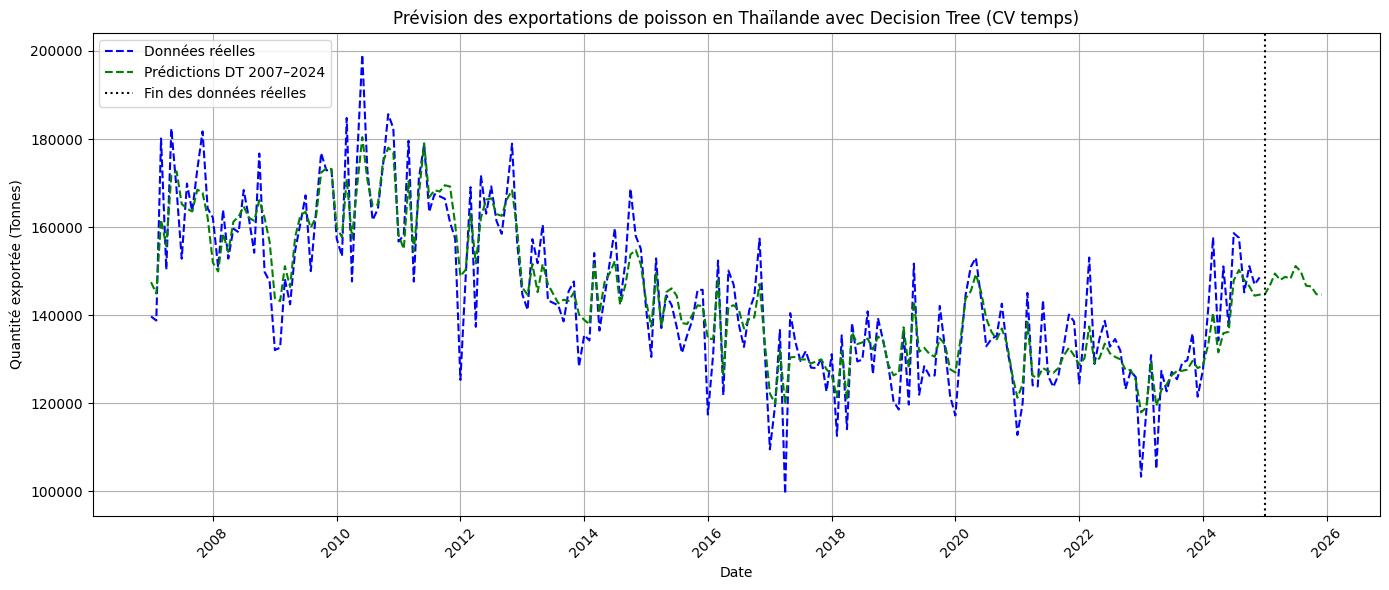

In [53]:
# features and target
X = df[['month_num', 'month_sin', 'month_cos', 
        'Chilled/Frozen Fresh Shrimp Quantity (Tons)',
        'Shrimp in Airtight Containers Quantity (Tons)',
        'Preserved or Processed Shrimp Quantity (Tons)',
        'Shrimp Quantity (Tons)',
        'Chilled/Frozen Fresh Squid Quantity (Tons)',
        'Dried Squid Quantity (Tons)',
        'Processed or Preserved Squid Quantity (Tons)',
        'Squid Quantity (Tons)',
        'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)',
        'Chilled/Frozen Fish Fillets Quantity (Tons)',
        'Dried Fish Quantity (Tons)',
        'Live Fish and Fish Breeding Stock Quantity (Tons)',
        'Fish Quantity (Tons)',
        'Canned Tuna Quantity (Tons)',
        'Canned Sardines Quantity (Tons)',
        'Other Canned Fish Quantity (Tons)',
        'Canned Crab Quantity (Tons)',
        'Other Canned Seafood Quantity (Tons)',
        'Canned Products Quantity (Tons)',
        'Canned Dog and Cat Food Quantity (Tons)',
        'Processed Seafood Products Quantity (Tons)',
        'Processed Tuna Products Quantity (Tons)',
        'Preserved or Processed Crab Quantity (Tons)',
        'Other Processed Seafood Products Quantity (Tons)',
        'Other Fishery Products Quantity (Tons)',
        ]]
y = df['Grand Total Quantity (Tons)'].values

# DecisionTree
model = RandomForestRegressor(max_depth= 20, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200)

# Temporal cross validation
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

# Training
model.fit(X, y)

# Months generation to 2025-12
all_months = pd.date_range(start=df['month'].min(), end="2025-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

mask = all_months != pd.to_datetime("2013-07-01")

all_months = all_months[mask]
all_month_nums = all_month_nums[mask]
all_month_sin = all_month_sin[mask]
all_month_cos = all_month_cos[mask]


# Forecasting
y_all_pred = model.predict(X_Future)

# Display
plt.figure(figsize=(14, 6))
plt.plot(df['month'], y, label="Données réelles",  linestyle="--",color='blue')
plt.plot(all_months, y_all_pred, label="Prédictions DT 2007–2024", linestyle="--", color='green')
plt.axvline(x=pd.to_datetime("2024-12-31"), color='black', linestyle=':', label='Fin des données réelles')
plt.xlabel("Date")
plt.ylabel("Quantité exportée (Tonnes)")
plt.title("Prévision des exportations de poisson en Thaïlande avec Decision Tree (CV temps)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()